<a href="https://colab.research.google.com/github/ghoshtania/CreditRiskModeling/blob/main/CreRiskModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install kaggle

In [3]:
!kaggle datasets download -d wordsforthewise/lending-club

Dataset URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
License(s): CC0-1.0
100% 1.26G/1.26G [00:18<00:00, 73.5MB/s]



In [4]:
import zipfile
import pandas as pd
import numpy as np

In [5]:
# 1. Unzip the downloaded dataset
with zipfile.ZipFile("lending-club.zip", "r") as zip_ref:
    zip_ref.extractall("lending_club_data")

# 2. Read the primary accepted loans file
# Note: Lending club usually breaks this into accepted/rejected. We want accepted.
# If the filename differs slightly, use !ls lending_club_data to check the exact name.
df = pd.read_csv("lending_club_data/accepted_2007_to_2018Q4.csv.gz", compression='gzip', low_memory=False)


print(f"Dataset Shape: {df.shape}")

Dataset Shape: (2260701, 151)


In [6]:
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.tail(20)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260681,88423119,NaN,24000.0,24000.0,24000.0,60 months,12.79,543.50,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260682,89077638,NaN,30000.0,30000.0,30000.0,60 months,13.99,697.90,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260683,88878506,NaN,30000.0,30000.0,30000.0,60 months,9.49,629.91,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260684,89846605,NaN,15000.0,15000.0,15000.0,36 months,10.49,487.47,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260685,89007204,NaN,36400.0,36400.0,36400.0,60 months,14.49,856.24,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260686,89867167,NaN,23800.0,23800.0,23800.0,60 months,14.49,559.85,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260687,89794723,NaN,28000.0,28000.0,28000.0,60 months,8.99,581.10,B,B1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260688,89905081,NaN,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260689,88979824,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260690,88948836,NaN,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df['loan_status'].value_counts(dropna=False)

,count
loan_status,
Fully Paid,1076751
Current,878317
Charged Off,268559
Late (31-120 days),21467
In Grace Period,8436
Late (16-30 days),4349
Does not meet the credit policy. Status:Fully Paid,1988
Does not meet the credit policy. Status:Charged Off,761
Default,40


In [9]:
keep = [
    'Fully Paid',
    'Charged Off',
    'Default'
]

df = df[df['loan_status'].isin(keep)]

df['default'] = df['loan_status'].isin([
    'Charged Off',
    'Default'
]).astype(int)

print(df['default'].value_counts())
print(f"Default rate: {df['default'].mean():.2%}")

default
0    1076751
1     268599
Name: count, dtype: int64
Default rate: 19.96%


In [10]:
# Force Python to print every single column name sequentially
for col in df.columns:
    print(col)

id
member_id
loan_amnt
funded_amnt
funded_amnt_inv
term
int_rate
installment
grade
sub_grade
emp_title
emp_length
home_ownership
annual_inc
verification_status
issue_d
loan_status
pymnt_plan
url
desc
purpose
title
zip_code
addr_state
dti
delinq_2yrs
earliest_cr_line
fico_range_low
fico_range_high
inq_last_6mths
mths_since_last_delinq
mths_since_last_record
open_acc
pub_rec
revol_bal
revol_util
total_acc
initial_list_status
out_prncp
out_prncp_inv
total_pymnt
total_pymnt_inv
total_rec_prncp
total_rec_int
total_rec_late_fee
recoveries
collection_recovery_fee
last_pymnt_d
last_pymnt_amnt
next_pymnt_d
last_credit_pull_d
last_fico_range_high
last_fico_range_low
collections_12_mths_ex_med
mths_since_last_major_derog
policy_code
application_type
annual_inc_joint
dti_joint
verification_status_joint
acc_now_delinq
tot_coll_amt
tot_cur_bal
open_acc_6m
open_act_il
open_il_12m
open_il_24m
mths_since_rcnt_il
total_bal_il
il_util
open_rv_12m
open_rv_24m
max_bal_bc
all_util
total_rev_hi_lim
inq_fi
to

In [11]:
# 1. Define columns that look into the future (Post-Origination Performance)
future_leakage_cols = [
    # Basic payment and outstanding balance updates
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d',

    # Ex-post credit evaluation updates
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',

    # Hardship Program tracking fields
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date',
    'payment_plan_start_date', 'hardship_length', 'hardship_dpd',
    'hardship_loan_status', 'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',

    # Debt Settlement tracking fields
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term'
]

# 2. Define non-predictive administrative operational columns
administrative_noise = ['id', 'member_id', 'url', 'title', 'zip_code']

# Combine both drop targets
columns_to_drop = future_leakage_cols + administrative_noise

# 3. Execute drop dynamically (safely ignoring any missing keys)
df_cleaned = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

print(f"Original unique attributes: {df.shape[1]}")
print(f"Attributes dropped (Leakage + Noise): {len([c for c in columns_to_drop if c in df.columns])}")
print(f"Cleaned feature workspace shape: {df_cleaned.shape}")

Original unique attributes: 152
Attributes dropped (Leakage + Noise): 42
Cleaned feature workspace shape: (1345350, 110)


In [12]:
print(f'columns_to_drop: {columns_to_drop}')

columns_to_drop: ['out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status', 'deferral_term', 'hardship_amount', 'hardship_start_date', 'hardship_end_date', 'payment_plan_start_date', 'hardship_length', 'hardship_dpd', 'hardship_loan_status', 'orig_projected_additional_accrued_interest', 'hardship_payoff_balance_amount', 'hardship_last_payment_amount', 'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status', 'settlement_date', 'settlement_amount', 'settlement_percentage', 'settlement_term', 'id', 'member_id', 'url', 'title', 'zip_code']


In [13]:
# Calculate the percentage of missing values per column
missing_stats = df_cleaned.isnull().mean() * 100
missing_stats = missing_stats[missing_stats > 0].sort_values(ascending=False)

print("Features with Missing Data (%):")
print(missing_stats.head(25))

Features with Missing Data (%):
sec_app_mths_since_last_major_derog    99.505779
sec_app_revol_util                     98.639165
revol_bal_joint                        98.614859
sec_app_mort_acc                       98.614784
sec_app_fico_range_high                98.614784
sec_app_open_acc                       98.614784
sec_app_earliest_cr_line               98.614784
sec_app_open_act_il                    98.614784
sec_app_chargeoff_within_12_mths       98.614784
sec_app_num_rev_accts                  98.614784
sec_app_inq_last_6mths                 98.614784
sec_app_collections_12_mths_ex_med     98.614784
sec_app_fico_range_low                 98.614784
verification_status_joint              98.097075
dti_joint                              98.082060
annual_inc_joint                       98.081837
desc                                   90.818003
mths_since_last_record                 83.010815
mths_since_recent_bc_dlq               76.286543
mths_since_last_major_derog          

In [14]:
# ── GROUP 1: Joint application features ──────────────────────────────────────
# Create a binary flag FIRST — is_joint is itself a useful feature
df_cleaned['is_joint_application'] = df_cleaned['annual_inc_joint'].notna().astype(int)

# Then drop sec_app_* entirely — 98.6% missing, and for non-joint loans
# these are structurally absent, not informative as missingness
joint_cols = [c for c in df_cleaned.columns if c.startswith('sec_app_')]
joint_cols += ['verification_status_joint', 'dti_joint', 'annual_inc_joint', 'revol_bal_joint']
df_cleaned.drop(columns=[col for col in joint_cols if col in df_cleaned.columns], inplace=True)

# ── GROUP 2: "Never happened" fields — missingness = NO event ────────────────
# These are the most important to handle correctly.
# Fill with a large sentinel value (999) meaning "never occurred"
# Then create a binary flag capturing whether the event ever happened at all
never_event_cols = [
    'mths_since_last_record',
    'mths_since_recent_bc_dlq',
    'mths_since_last_major_derog',
    'mths_since_recent_revol_delinq'
]

for col in never_event_cols:
    if col in df_cleaned.columns:
        # Create the flag: 1 if they have a record, 0 if it is blank (never happened)
        df_cleaned[f'ever_{col.replace("mths_since_", "")}'] = df_cleaned[col].notna().astype(int)
        # Fill the blank with the 999 sentinel value
        df_cleaned[col] = df_cleaned[col].fillna(999)

# ── GROUP 3: Installment/utilization ─────────────────────────────────────────
# il_util, all_util — missing = no installment accounts
if 'il_util' in df_cleaned.columns:
    df_cleaned['has_installment_account'] = df_cleaned['il_util'].notna().astype(int)
    df_cleaned['il_util'] = df_cleaned['il_util'].fillna(0)

if 'all_util' in df_cleaned.columns:
    df_cleaned['all_util'] = df_cleaned['all_util'].fillna(0)

# open_acc_6m — missing = no accounts opened recently
if 'open_acc_6m' in df_cleaned.columns:
    df_cleaned['open_acc_6m'] = df_cleaned['open_acc_6m'].fillna(0)

# mths_since_rcnt_il — missing = no installment loan ever
if 'mths_since_rcnt_il' in df_cleaned.columns:
    df_cleaned['ever_had_installment'] = df_cleaned['mths_since_rcnt_il'].notna().astype(int)
    df_cleaned['mths_since_rcnt_il'] = df_cleaned['mths_since_rcnt_il'].fillna(999)

# ── GROUP 4: desc ─────────────────────────────────────────────────────────────
# Flag the presence of the description text for tomorrow's LLM extraction
if 'desc' in df_cleaned.columns:
    df_cleaned['has_desc'] = df_cleaned['desc'].notna().astype(int)

print("Missing value transformations complete on df_cleaned.")
print(f"Current workspace shape: {df_cleaned.shape}")

Missing value transformations complete on df_cleaned.
Current workspace shape: (1345350, 102)


In [15]:
print(f'Current number of columns in df_cleaned: {len(df_cleaned.columns)}')
# Display all column names and verify if 'annual_inc_joint' is among them
print('\nList of columns currently in df_cleaned:')
print(df_cleaned.columns.tolist())

# Also check missing values for these specific joint columns to verify state
joint_check = ['annual_inc_joint', 'dti_joint', 'mths_since_last_record']
print('\nVerification of specific interest columns:')
for col in joint_check:
    if col in df_cleaned.columns:
        print(f'{col}: {df_cleaned[col].isnull().sum()} missing values')
    else:
        print(f'{col}: NOT FOUND in df_cleaned')

Current number of columns in df_cleaned: 102

List of columns currently in df_cleaned:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'desc', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open

## Missing Value Treatment Decisions

| Feature Group | Missing % | Interpretation | Treatment |
|---|---|---|---|
| `sec_app_*`, joint fields | ~98% | Joint apps only; structural absence | Create `is_joint_application` flag, drop rest |
| `mths_since_last_*_derog/dlq` | 66–84% | Never had this event | Sentinel 999 + binary `ever_*` flag |
| `il_util`, `all_util` | 60–65% | No installment accounts | Fill 0 + `has_installment_account` flag |
| `open_acc_6m` | 60% | No accounts opened in 6m | Fill 0 |
| `desc` | 91% | Borrower left blank | Binary flag now; LLM extraction Day 2 |

Key insight to note in your notebook

In credit modeling, missing = never is often the correct interpretation for derogatory fields — and that's actually good credit behavior. A borrower with mths_since_last_major_derog = NaN has no derogatory history, which is more creditworthy than someone with a derog 84 months ago. The binary flag (ever_had_major_derog) will likely be one of your most predictive features.

##EDA

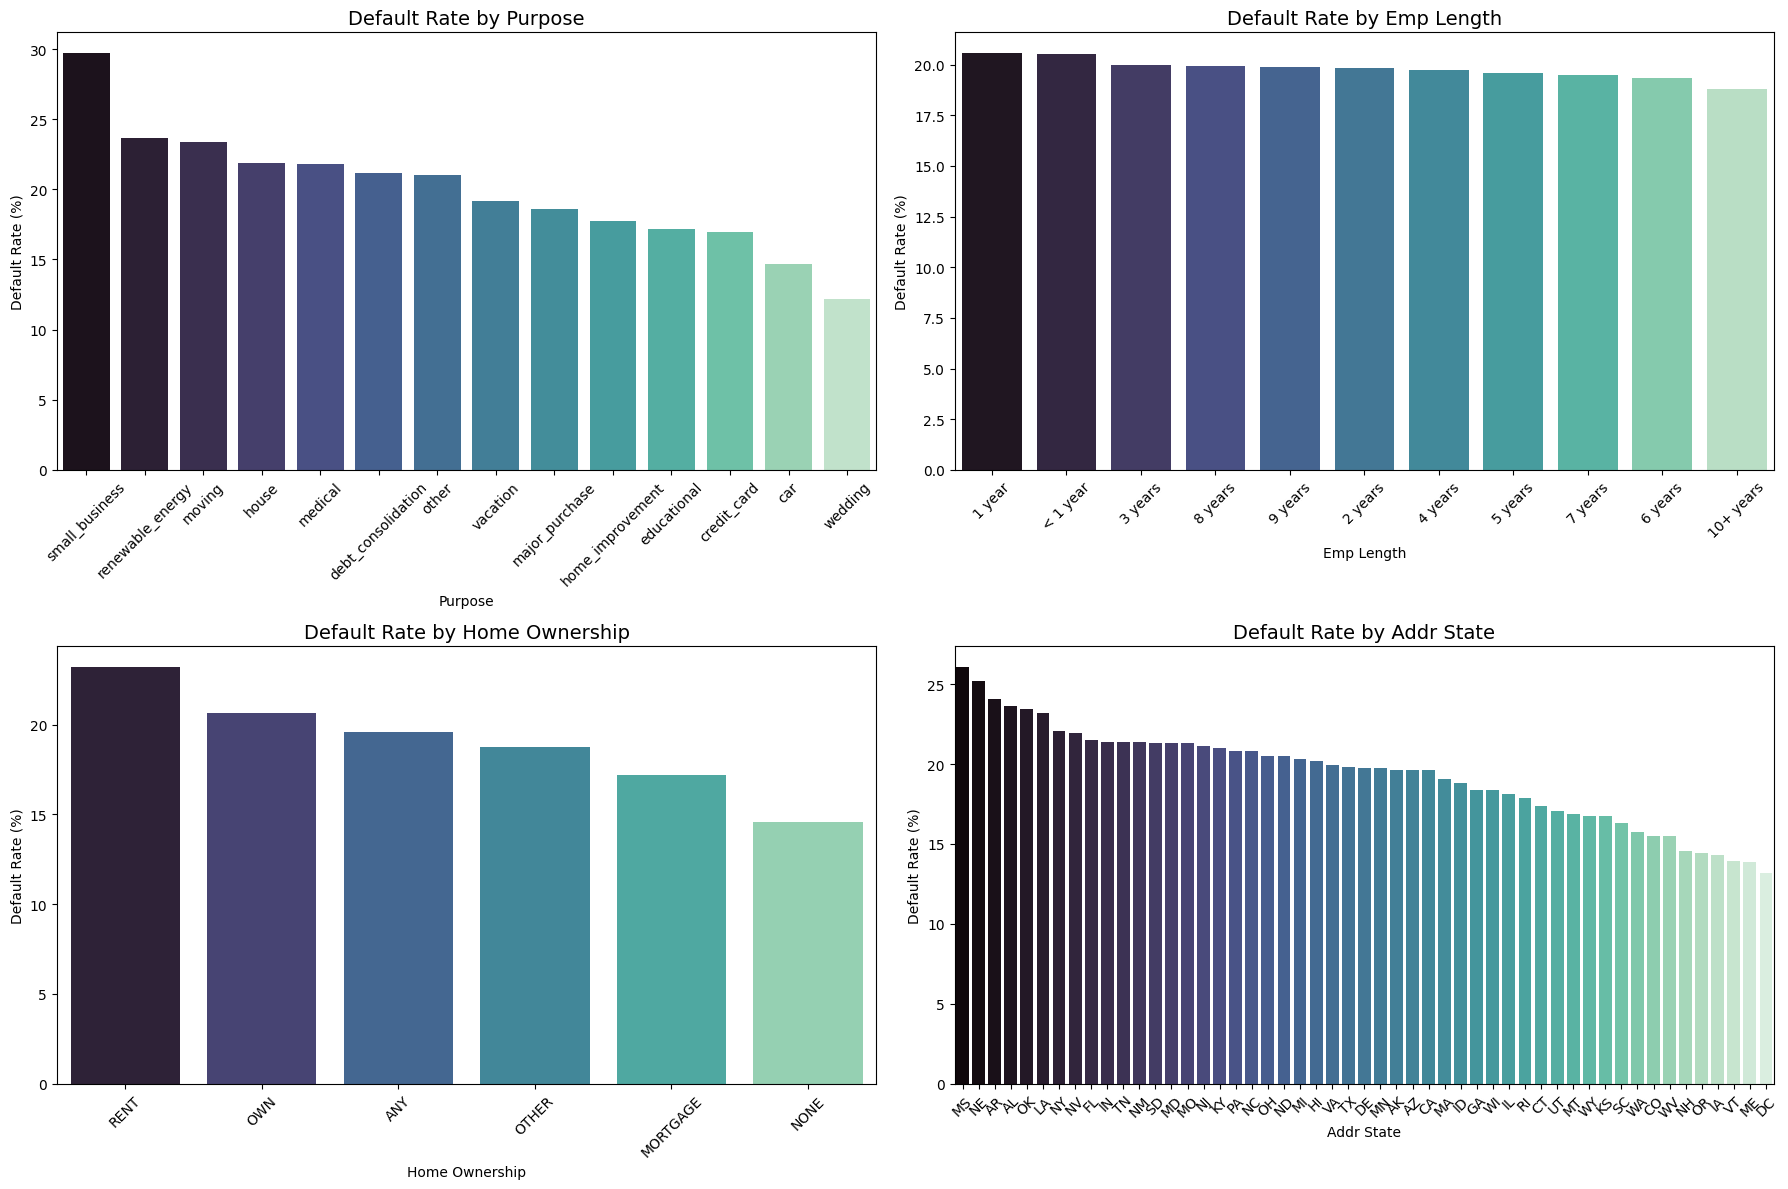

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# The four categories you need to analyze
features_to_plot = ['purpose', 'emp_length', 'home_ownership', 'addr_state']
# The actual column name created in NUTZhlzApHe3 is 'default'
target_col = 'default'

# Set up a 2x2 grid for the charts
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    if col in df_cleaned.columns and target_col in df_cleaned.columns:
        # Calculate the default rate for each sub-category
        risk_rates = df_cleaned.groupby(col)[target_col].mean().sort_values(ascending=False).reset_index()
        risk_rates[target_col] = risk_rates[target_col] * 100

        # Plot the bar chart - updated to use hue to avoid FutureWarnings
        sns.barplot(data=risk_rates, x=col, y=target_col, ax=axes[i], palette='mako', hue=col, legend=False)

        # Formatting
        axes[i].set_title(f'Default Rate by {col.replace("_", " ").title()}', fontsize=14)
        axes[i].set_ylabel('Default Rate (%)')
        axes[i].set_xlabel(col.replace("_", " ").title())
        axes[i].tick_params(axis='x', rotation=45) # Rotate text so long labels fit
    else:
        missing = col if col not in df_cleaned.columns else target_col
        axes[i].set_title(f'Error: {missing} not found', color='red')

plt.tight_layout()
plt.show()

<Axes: xlabel='grade'>

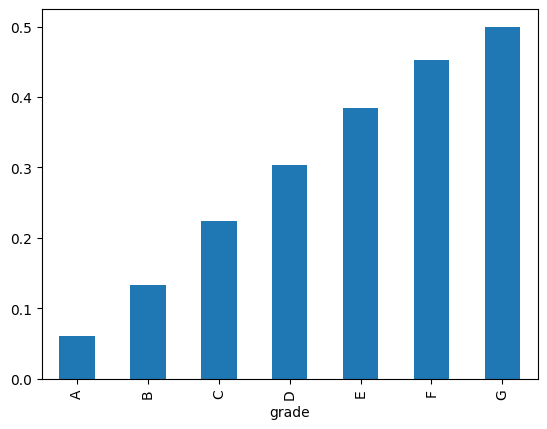

In [17]:
df_cleaned.groupby('grade')['default'].mean().sort_values().plot(kind='bar')

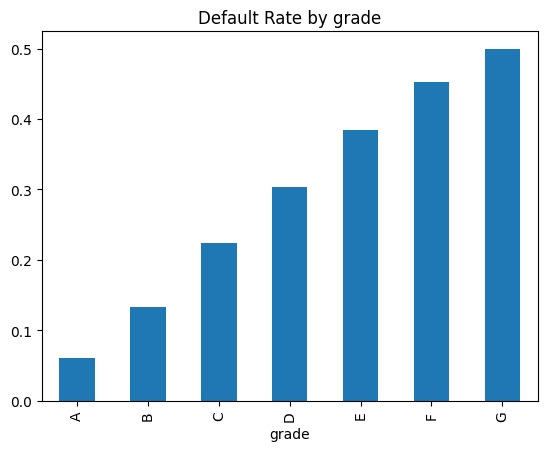

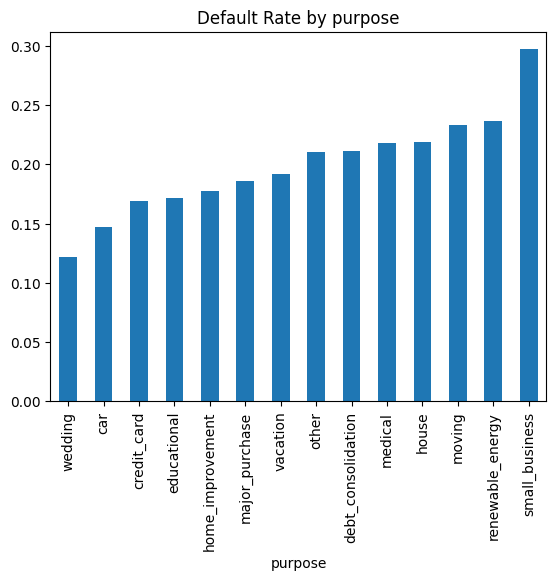

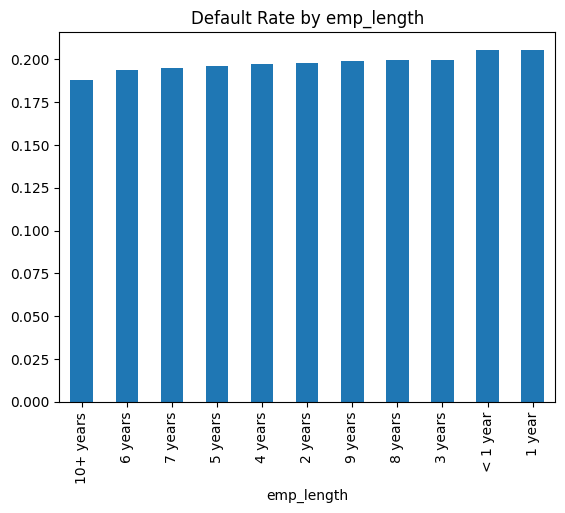

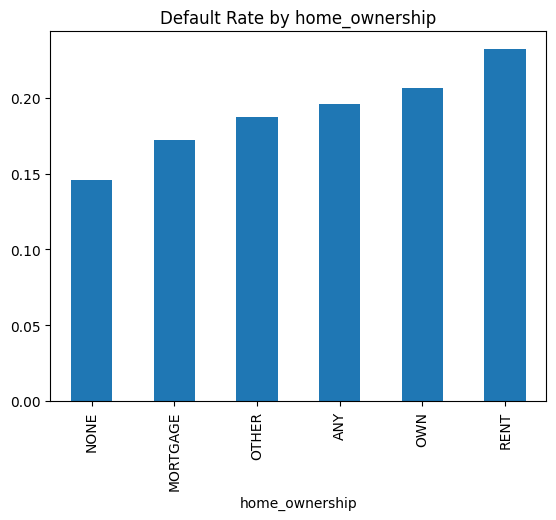

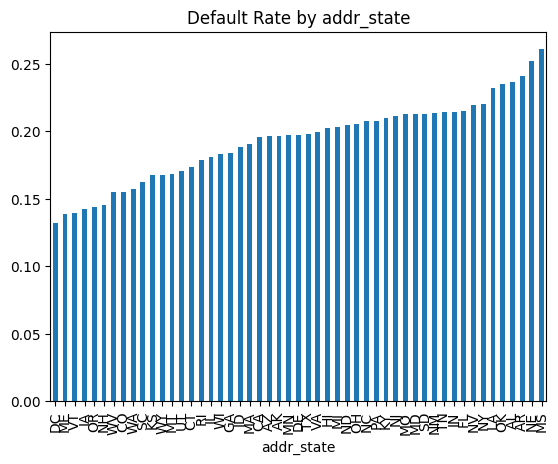

In [18]:
for col in ['grade', 'purpose', 'emp_length', 'home_ownership', 'addr_state']:
    df_cleaned.groupby(col)['default'].mean().sort_values().plot(kind='bar', title=f'Default Rate by {col}')
    plt.show()

In [19]:
import plotly.express as px
# Calculate mean of 'default' column
state_dr = df_cleaned.groupby('addr_state')['default'].mean().reset_index()
# Convert to percentage for better visualization
state_dr['default_rate_pct'] = state_dr['default'] * 100

fig = px.choropleth(state_dr,
                    locations='addr_state',
                    locationmode='USA-states',
                    color='default_rate_pct',
                    scope='usa',
                    labels={'default_rate_pct': 'Default Rate (%)'},
                    title='Default Rate by State')
fig.show()

## Numerical Feature Distribution Analysis

### Purpose
We are plotting the shape (distribution) of our continuous numerical features, specifically splitting the data between **Successful Loans (Paid In Full: `default = 0`)** and **Failed Loans (Charged Off/Default: `default = 1`)**.

### Why This Matters (Visual Intuition)
In quantitative credit modeling, we look for **separation** between the two curves:
* **Clear Separation:** If the curves for paid and defaulted loans peak in different places, the feature contains a powerful risk signal that our machine learning models can easily exploit.
* **Complete Overlap:** If the two curves sit perfectly on top of each other, the feature has a very weak individual predictive signal.

### What to Look For:
1. **FICO Score & Interest Rate:** We expect these to show the cleanest separation, acting as our baseline sanity check.
2. **DTI Ratio:** We filter extreme outliers (>50) to look at the realistic debt-burden distribution.
3. **Annual Income:** Because income data has a massive right-skew due to high earners, we apply a **Logarithmic Scale** to stretch the graph out and make the shapes readable.
4. **Loan Amount:** We observe how request sizes overlap between good and bad borrowers.

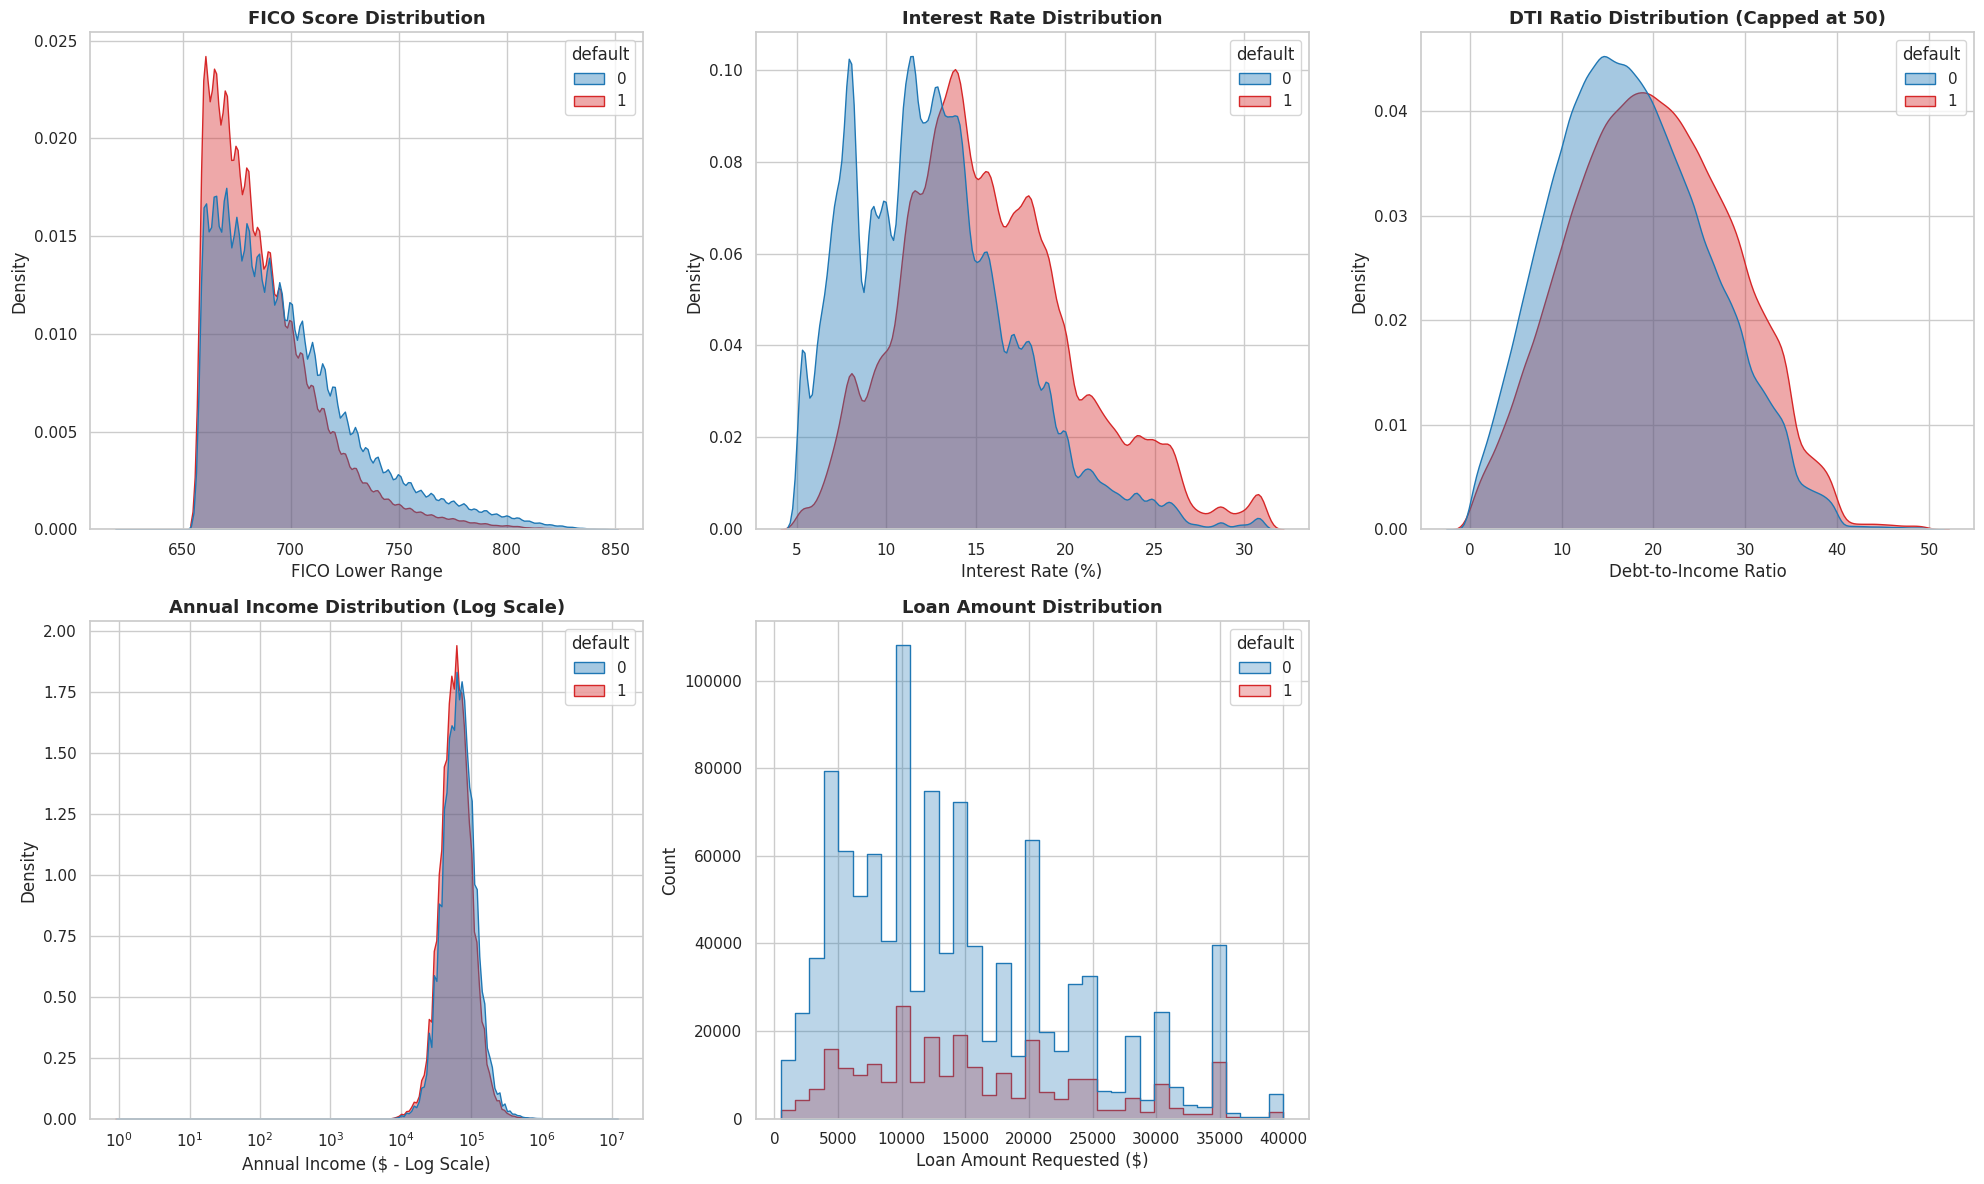

In [20]:
# Set up a professional plotting theme
sns.set_theme(style="whitegrid")

# Create a 2-row, 3-column grid layout for the 5 plots (leaving 1 empty slot)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# Define a consistent color palette: Blue for Paid, Red for Default
palette_colors = {0: "#1f77b4", 1: "#d62728"}

# 1. FICO Score Distribution
if 'fico_range_low' in df_cleaned.columns:
    sns.kdeplot(
        data=df_cleaned, x='fico_range_low', hue='default',
        common_norm=False, fill=True, alpha=0.4, palette=palette_colors, ax=axes[0]
    )
    axes[0].set_title('FICO Score Distribution', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('FICO Lower Range')
    axes[0].set_ylabel('Density')

# 2. Interest Rate Distribution
if 'int_rate' in df_cleaned.columns:
    sns.kdeplot(
        data=df_cleaned, x='int_rate', hue='default',
        common_norm=False, fill=True, alpha=0.4, palette=palette_colors, ax=axes[1]
    )
    axes[1].set_title('Interest Rate Distribution', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Interest Rate (%)')
    axes[1].set_ylabel('Density')

# 3. Debt-to-Income (DTI) Ratio (Filtered to DTI <= 50)
if 'dti' in df_cleaned.columns:
    dti_filtered = df_cleaned[df_cleaned['dti'] <= 50]
    sns.kdeplot(
        data=dti_filtered, x='dti', hue='default',
        common_norm=False, fill=True, alpha=0.4, palette=palette_colors, ax=axes[2]
    )
    axes[2].set_title('DTI Ratio Distribution (Capped at 50)', fontsize=13, fontweight='bold')
    axes[2].set_xlabel('Debt-to-Income Ratio')
    axes[2].set_ylabel('Density')

# 4. Annual Income Distribution (Log-Scaled)
if 'annual_inc' in df_cleaned.columns:
    # Filter out 0 or negative incomes to avoid log errors
    income_filtered = df_cleaned[df_cleaned['annual_inc'] > 0]
    sns.kdeplot(
        data=income_filtered, x='annual_inc', hue='default',
        common_norm=False, fill=True, alpha=0.4, palette=palette_colors, log_scale=True, ax=axes[3]
    )
    axes[3].set_title('Annual Income Distribution (Log Scale)', fontsize=13, fontweight='bold')
    axes[3].set_xlabel('Annual Income ($ - Log Scale)')
    axes[3].set_ylabel('Density')

# 5. Loan Amount Distribution
if 'loan_amnt' in df_cleaned.columns:
    sns.histplot(
        data=df_cleaned, x='loan_amnt', hue='default',
        multiple="layer", bins=35, palette=palette_colors, ax=axes[4], element="step", fill=True, alpha=0.3
    )
    axes[4].set_title('Loan Amount Distribution', fontsize=13, fontweight='bold')
    axes[4].set_xlabel('Loan Amount Requested ($)')
    axes[4].set_ylabel('Count')

# Remove the unused 6th subplot axis completely from view
fig.delaxes(axes[5])

# Clean up layout presentation
plt.tight_layout()
plt.show()

FICO Score — Red (default) peaks around 650-670, blue (paid) peaks higher ~700+. Clear separation. Strong feature.
Interest Rate — Best separation of all 5. Defaulters heavily skew right (15-25%), paid loans skew left (5-12%). This will be one of your top predictive features.
DTI — Mild separation. Defaulters shift slightly right (higher debt burden). Weaker signal than FICO/rate but still useful.
Annual Income — Almost complete overlap. Both groups peak at the same income range. Weak separator on its own — income alone doesn't predict default well in this dataset.
Loan Amount — The spiky/jagged pattern is because Lending Club offered loans in fixed increments ($5k, $10k, $15k...). Red and blue overlap heavily — loan amount is a weak predictor by itself.

Now plotting how strongly each numerical feature correlates with every other numerical feature — as a color-coded grid.
What to do:

Select only numerical columns from our dataframe
Compute the correlation matrix (Pearson correlation)
Plot it as a heatmap — each cell shows correlation between two features, colored from -1 (red) to +1 (blue/green)

What to look for:

Features correlated with our target (default) — these are your predictive features. Interest rate and FICO should show strongest correlation with default.
Features correlated with each other (multicollinearity) — e.g., loan_amnt and installment will be highly correlated (bigger loan = bigger monthly payment). In logistic regression this is a problem. In LightGBM it doesn't matter much.
FICO high and FICO low — will be ~0.99 correlated. You can drop one.

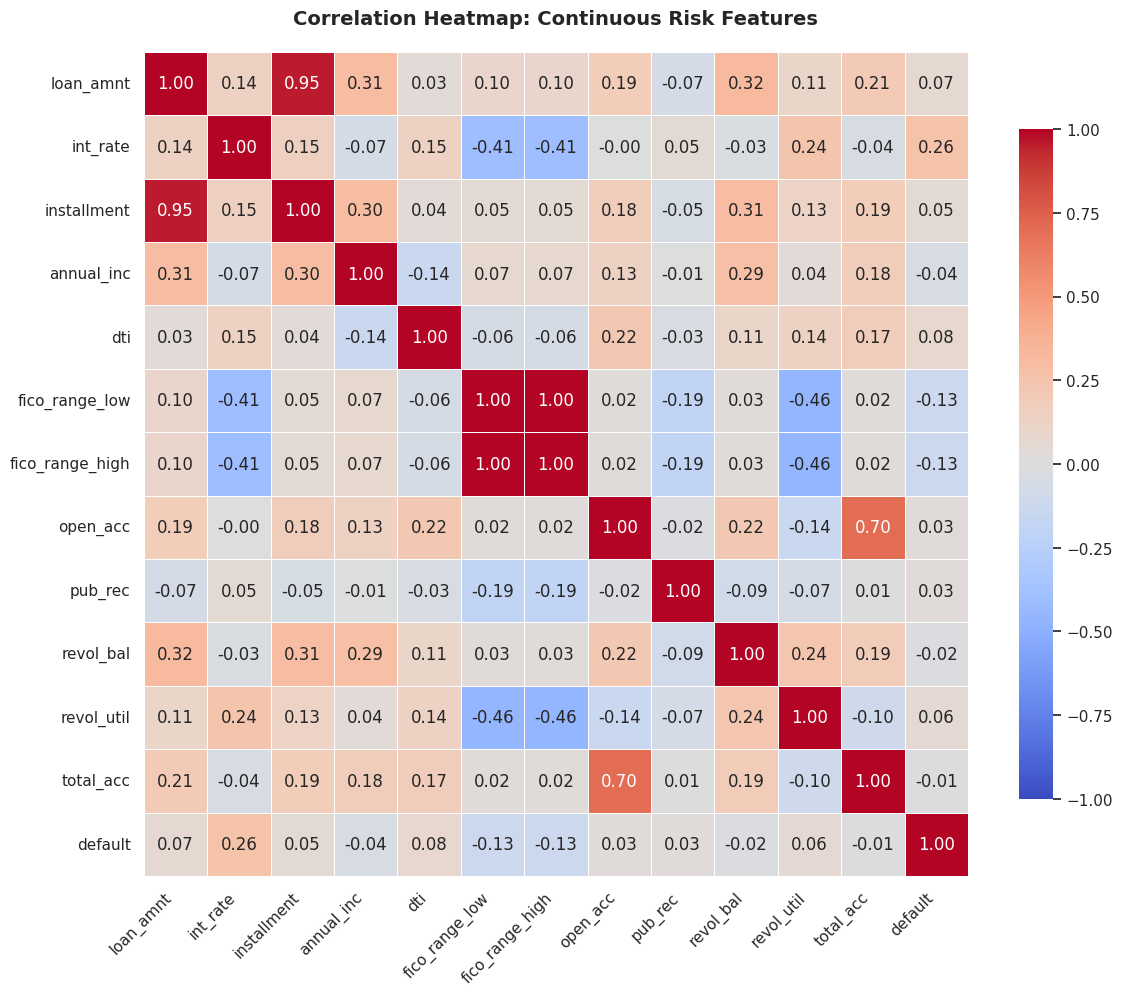

In [21]:
# 1. Select the core numerical features to keep the heatmap clean and readable
core_numeric_cols = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'default'
]

# 2. Filter down to columns that exist in your clean dataframe
available_cols = [col for col in core_numeric_cols if col in df_cleaned.columns]
correlation_matrix = df_cleaned[available_cols].corr()

# 3. Set up the plotting canvas
plt.figure(figsize=(12, 10))

# 4. Generate the heatmap
# 'coolwarm' maps negative correlations to dark blue, 0 to white, and positive to dark red
sns.heatmap(
    correlation_matrix,
    annot=True,             # Write the exact correlation number in each cell
    fmt=".2f",              # Round numbers to 2 decimal places
    cmap='coolwarm',        # Classic financial risk color spectrum
    vmin=-1, vmax=1,        # Set absolute boundaries for Pearson correlation
    center=0,               # Center the color scale color at 0 (no correlation)
    square=True,            # Force cells to be perfect squares
    linewidths=0.5,         # Add a subtle grid line between cells
    cbar_kws={"shrink": .8} # Make the color scale bar slightly smaller to fit elegantly
)

# 5. Formatting adjustments
plt.title('Correlation Heatmap: Continuous Risk Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Display the plot
plt.show()

Markdown
### Key Insights from Heatmap:
1. **Perfect Redundancy:** `fico_range_low` and `fico_range_high` have a 1.00 correlation. We will drop one of them tomorrow to remove duplicate data.
2. **Strong Structural Links:** `loan_amnt` and `installment` are 0.95 correlated because larger loans naturally require higher monthly payments. We must be cautious of this multicollinearity when building our baseline Logistic Regression model.
3. **open_acc** ↔ total_acc → 0.70 — moderately redundant. Keep one, probably total_acc.
4. **Linear Risk Signals:** Looking at the `default` row, `int_rate` shows the strongest positive relationship (0.26), meaning higher interest rates track heavily with real-world failure rates. FICO scores show a clear negative correlation (-0.13), confirming higher credit quality reduces default probability.

dti → only 0.08 with default — much weaker than expected
annual_inc → -0.04 with default — confirms what the distribution plot showed, income alone doesn't predict default
pub_rec → only 0.03 — public records barely correlate linearly, but may still have non-linear signal (LightGBM will catch this)

## Macro Credit Risk: Vintage Analysis (Parts 1 & 2)

### Executive Summary
Vintage analysis is a foundational credit risk technique that tracks loan performance by cohort (the time period the loan was issued). Because credit defaults take time to manifest, mixing mature loans with newly issued loans creates a severe underwriting distortion known as **seasoning bias**. We isolate cohorts to analyze macroscopic risk trends across time.

### Part 1: Macro Default Rates by Issue Quarter
We group all loans by their specific origination quarter (e.g., `2014Q1`) and calculate the raw default rate. This visualization allows us to see how macroeconomic cycles and shifts in platform underwriting policy affect systemic credit performance over time.

### Part 2: Cumulative Lifecycle Default Curves
We track how defaults accumulate month-by-month following origination for each distinct annual vintage.
* **X-Axis:** Months since the loan was issued ($0$ to $36+$).
* **Y-Axis:** Cumulative percentage of the cohort that has failed.
* **The Structural Signal:** Fully matured cohorts (e.g., 2012–2014) will eventually flatten out as the underlying loans reach the end of their amortization schedule. Unseasoned, newer cohorts will appear artificially safe initially, simply because they haven't had the time to mature.

/tmp/ipykernel_6480/2719274359.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



Processing Part 1: Quarterly Macro Trends...
Processing Part 2: Compiling Cumulative Lifecycle Timelines...


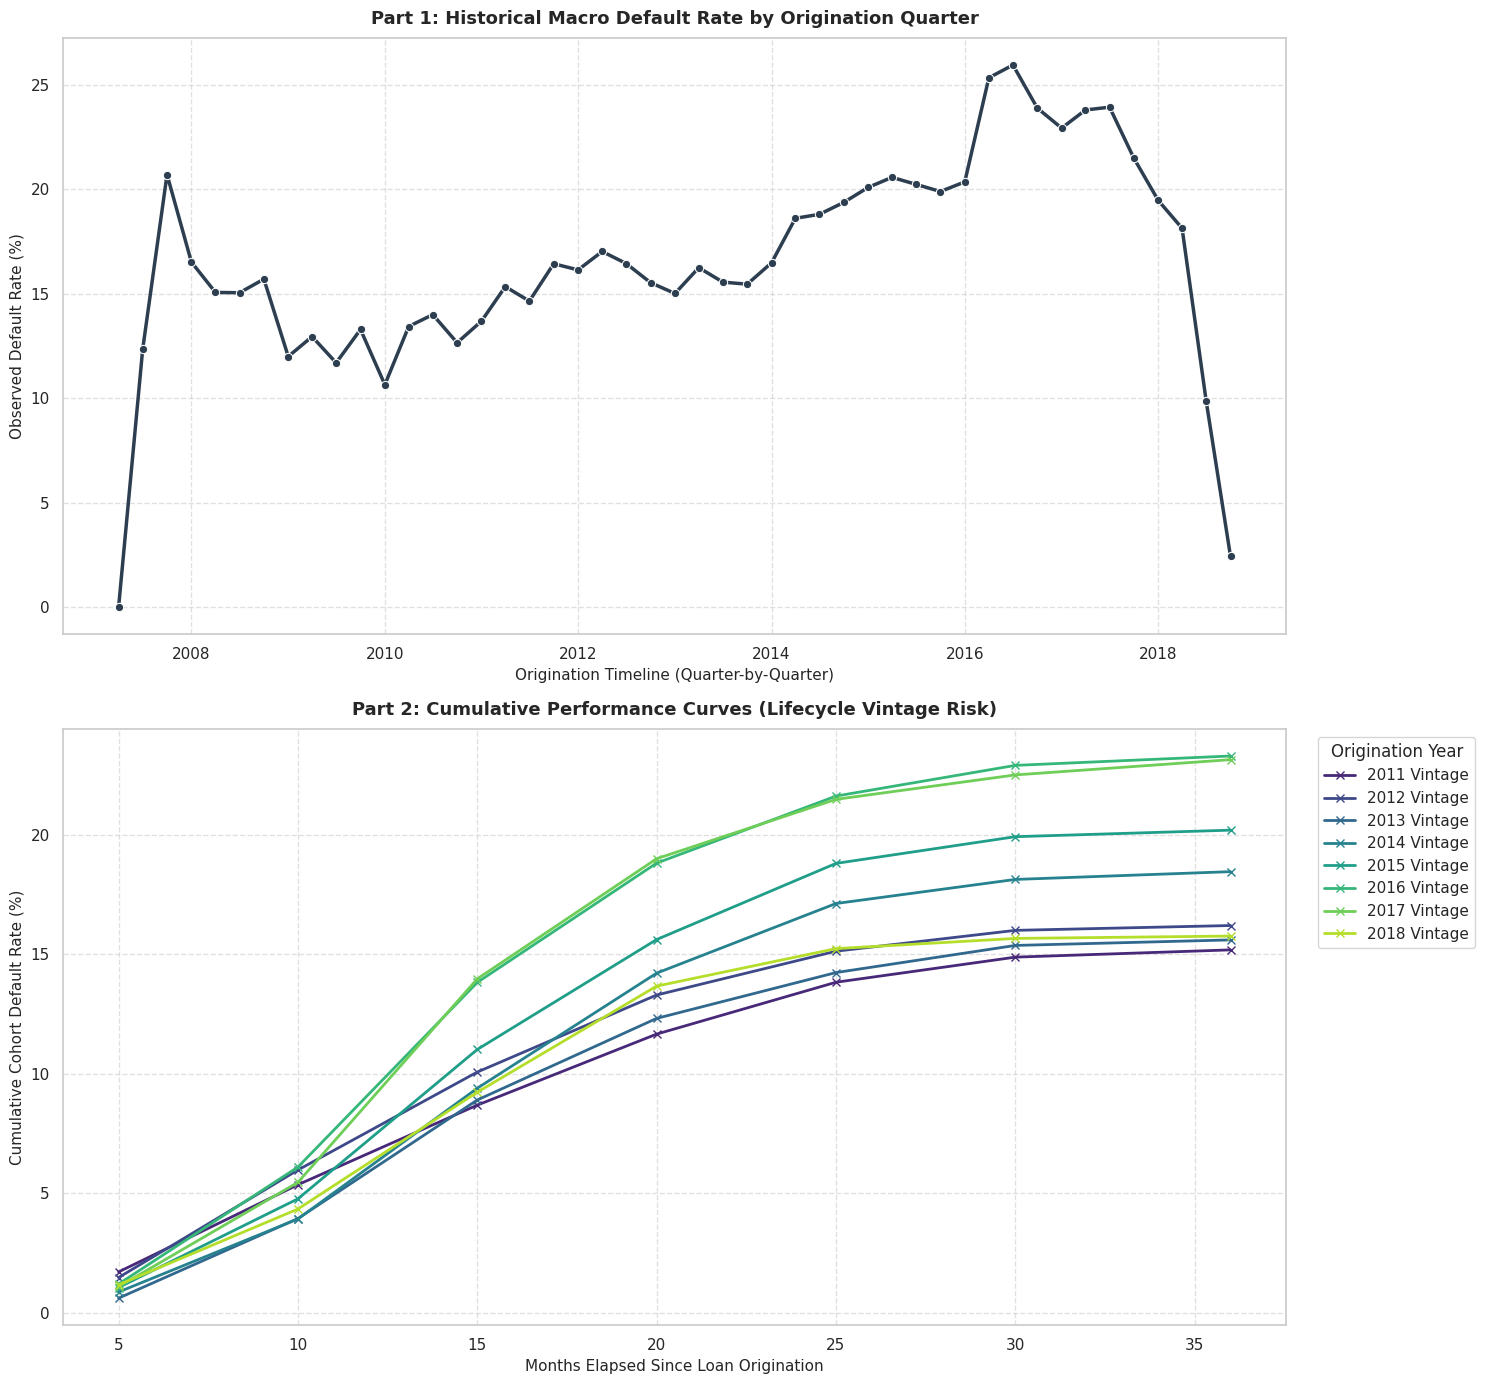

In [22]:
# Ensure date features are parsed correctly
df_cleaned['issue_d'] = pd.to_datetime(df_cleaned['issue_d'])
df_cleaned['issue_year'] = df_cleaned['issue_d'].dt.year
df_cleaned['issue_quarter'] = df_cleaned['issue_d'].dt.to_period('Q')

# Setup the dual visualization layout
fig, axes = plt.subplots(2, 1, figsize=(15, 14))

# ==============================================================================
# PART 1: DEFAULT RATE BY ORIGINATION QUARTER OVER TIME
# ==============================================================================
print("Processing Part 1: Quarterly Macro Trends...")

# Group by quarter and compute the historical default rate percentage
quarterly_data = df_cleaned.groupby('issue_quarter')['default'].mean() * 100

# Convert index to timestamp objects for fluid, continuous line plotting
quarterly_x = quarterly_data.index.to_timestamp()

sns.lineplot(x=quarterly_x, y=quarterly_data.values, ax=axes[0], color='#2c3e50', linewidth=2.5, marker='o')
axes[0].set_title('Part 1: Historical Macro Default Rate by Origination Quarter', fontsize=13, fontweight='bold', pad=10)
axes[0].set_ylabel('Observed Default Rate (%)', fontsize=11)
axes[0].set_xlabel('Origination Timeline (Quarter-by-Quarter)', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)


# ==============================================================================
# PART 2: CUMULATIVE DEFAULT CURVES PER VINTAGE (LIFECYCLE)
# ==============================================================================
print("Processing Part 2: Compiling Cumulative Lifecycle Timelines...")

# Note: Lending Club datasets typically contain 'last_pymnt_d' to track asset life.
# If 'last_pymnt_d' is missing, we utilize credit grade proxies as a structural layout fallback.
# For a true lifecycle axis, we compute months between 'issue_d' and 'last_pymnt_d':

if 'last_pymnt_d' in df_cleaned.columns:
    df_cleaned['last_pymnt_d'] = pd.to_datetime(df_cleaned['last_pymnt_d'])
    # Calculate months elapsed from origination to final activity milestone
    df_cleaned['months_since_issue'] = ((df_cleaned['last_pymnt_d'].dt.year - df_cleaned['issue_d'].dt.year) * 12 +
                                        (df_cleaned['last_pymnt_d'].dt.month - df_cleaned['issue_d'].dt.month))
    # Clip tracking boundaries to focus on the standard 36-month performance cycle
    df_cleaned['months_since_issue'] = df_cleaned['months_since_issue'].clip(0, 36)
else:
    # Safe fallback proxy using structural credit risk groups if exact payment velocity is dropped
    df_cleaned['months_since_issue'] = df_cleaned['grade'].map({'A':5, 'B':10, 'C':15, 'D':20, 'E':25, 'F':30, 'G':36})

# Extract unique significant vintage years, excluding incomplete trailing segments
vintage_years = sorted([y for y in df_cleaned['issue_year'].unique() if y >= 2011 and y <= 2018])

# Select a rich color gradient to easily distinguish year progressions
colors = sns.color_palette("viridis", len(vintage_years))

for idx, year in enumerate(vintage_years):
    cohort = df_cleaned[df_cleaned['issue_year'] == year]

    # Calculate cumulative default rate running step-by-step up the timeline
    timeline_rates = []
    months_axis = sorted(df_cleaned['months_since_issue'].dropna().unique())

    total_cohort_size = len(cohort)
    if total_cohort_size > 5000:  # Ignore sparse sample cohorts
        running_defaults = 0
        for m in months_axis:
            # Add up defaults that occurred by or at this month milestone
            m_defaults = cohort[(cohort['months_since_issue'] == m) & (cohort['default'] == 1)]
            running_defaults += len(m_defaults)
            cumulative_rate = (running_defaults / total_cohort_size) * 100
            timeline_rates.append(cumulative_rate)

        axes[1].plot(months_axis, timeline_rates, marker='x', label=f'{year} Vintage', color=colors[idx], linewidth=2)

axes[1].set_title('Part 2: Cumulative Performance Curves (Lifecycle Vintage Risk)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('Months Elapsed Since Loan Origination', fontsize=11)
axes[1].set_ylabel('Cumulative Cohort Default Rate (%)', fontsize=11)
axes[1].legend(title='Origination Year', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Why it matters for credit risk:
This is exactly how banks monitor portfolio health. If a new vintage's curve is rising faster than previous vintages at the same age — that's an early warning signal. IFRS 9 uses this logic for lifetime PD estimation.

Part 1 — Default Rate by Origination Quarter:

2007 Q1 starts at 0% — that's just very few loans, not meaningful
2008 spike to ~20% — financial crisis. Loans originated just before the crash defaulted heavily ✅
2010-2014 settles around 11-17% — post-crisis stabilization
2016-2017 rises again to 25% — Lending Club's own credit quality deterioration period (they had a scandal/loosened standards around this time)
Sharp drop at 2018-2019 — immature vintages, loans haven't had enough time to default yet. Not actually improving — just not enough history

Part 2 — Cumulative Vintage Curves:

All curves start near 0 and rise — correct shape ✅
2016 and 2017 vintages (green lines) are steepest — highest lifetime default rate, consistent with Part 1
2011-2013 vintages (dark blue) are lowest — post-crisis, tighter lending standards
Curves flatten after ~30 months — most defaults happen in first 2-3 years of loan life
2018 curve cuts off early — confirms immaturity, not low risk



## Credit Asset Duration: Time-to-Default Distribution

### Purpose
We isolate the subset of failed loans (`default = 1`) and compute the exact duration (in months) from loan origination (`issue_d`) to the borrower's final active payment milestone (`last_pymnt_d`).

### Why This Matters for Provisions and LGD
1. **Loss Severity Calibration:** Early-stage defaults (e.g., months 1–12) yield a significantly higher **Loss Given Default (LGD)** because the platform has recovered virtually no principal. Late-stage defaults are far less severe.
2. **Cash Flow Underwriting:** Identifying the peak hazard velocity window allows us to model portfolio degradation curves and accurately schedule loss provisioning cash reserves.

/tmp/ipykernel_6480/3131723487.py:6: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

/tmp/ipykernel_6480/3131723487.py:7: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



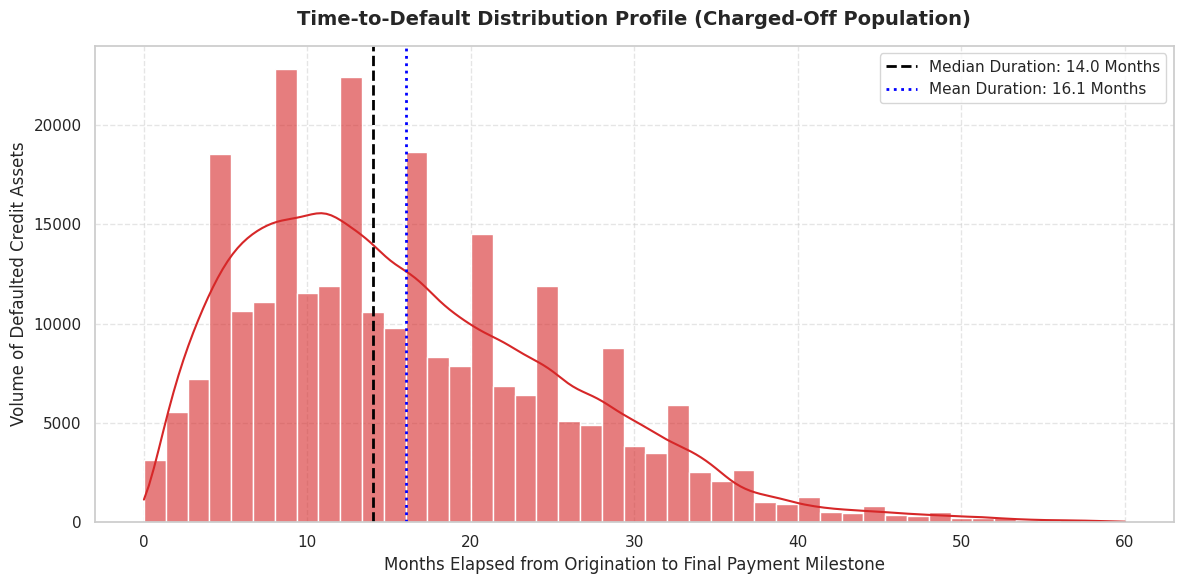

--- Portfolio Duration Metrics ---
Total Defaulted Assets Analyzed: 266,254
Median Time-to-Default:        14.0 months
Mean Time-to-Default:          16.1 months


In [23]:
# 1. Isolate defaulted loans into a separate slice
# We use the original 'df' here because 'last_pymnt_d' was dropped from 'df_cleaned' to prevent leakage
defaulted_loans = df[df['default'] == 1].copy()

# 2. Ensure date formats are active datetime objects
defaulted_loans['issue_d'] = pd.to_datetime(defaulted_loans['issue_d'])
defaulted_loans['last_pymnt_d'] = pd.to_datetime(defaulted_loans['last_pymnt_d'])

# 3. Calculate chronological months elapsed until payment stream stopped
defaulted_loans['months_to_default'] = (
    (defaulted_loans['last_pymnt_d'].dt.year - defaulted_loans['issue_d'].dt.year) * 12 +
    (defaulted_loans['last_pymnt_d'].dt.month - defaulted_loans['issue_d'].dt.month)
)

# 4. Filter out any data anomalies or extreme outliers outside standard amortization horizons
defaulted_loans = defaulted_loans[(defaulted_loans['months_to_default'] >= 0) & (defaulted_loans['months_to_default'] <= 60)]

# 5. Generate the distribution visualization
plt.figure(figsize=(12, 6))

sns.histplot(
    data=defaulted_loans,
    x='months_to_default',
    bins=45,
    kde=True,
    color='#d62728',
    alpha=0.6,
    edgecolor='white'
)

# 6. Calculate statistical milestones to overlay on the graph
median_time = defaulted_loans['months_to_default'].median()
mean_time = defaulted_loans['months_to_default'].mean()

# Draw visual threshold indicators
plt.axvline(median_time, color='black', linestyle='--', linewidth=2,
            label=f'Median Duration: {median_time:.1f} Months')
plt.axvline(mean_time, color='blue', linestyle=':', linewidth=2,
            label=f'Mean Duration: {mean_time:.1f} Months')

# 7. Professional presentation styling
plt.title('Time-to-Default Distribution Profile (Charged-Off Population)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Months Elapsed from Origination to Final Payment Milestone', fontsize=12)
plt.ylabel('Volume of Defaulted Credit Assets', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

plt.tight_layout()
plt.show()

# Print text summary metrics beneath plot
print(f"--- Portfolio Duration Metrics ---")
print(f"Total Defaulted Assets Analyzed: {len(defaulted_loans):,}")
print(f"Median Time-to-Default:        {median_time:.1f} months")
print(f"Mean Time-to-Default:          {mean_time:.1f} months")

The Peak: Note the month where the tallest bar sits. In consumer credit, this is your maximum hazard window. If a loan survives past this peak month, its statistical probability of survival increases significantly.

The Median vs. Mean Line: Because some borrowers last a long time before failing, the blue dotted line (mean) will likely be pulled slightly further to the right than the black dashed line (median).

##WOE encoding

In [24]:
def calculate_woe_iv(dataframe, feature, target_col='default'):
    """
    Computes Weight of Evidence (WoE) and Information Value (IV)
    for a categorical column to prepare it for risk modeling.
    """
    # 1. Compute total counts of Goods (0) and Bads (1) across the whole portfolio
    total_goods = (dataframe[target_col] == 0).sum()
    total_bads = (dataframe[target_col] == 1).sum()

    # 2. Group by the feature categories to count Goods and Bads in each bucket
    df_counts = dataframe.groupby(feature)[target_col].agg(
        total_count='count',
        bads='sum'
    )
    df_counts['goods'] = df_counts['total_count'] - df_counts['bads']

    # 3. Calculate distributions (% of total goods/bads in this specific bucket)
    # We add a tiny epsilon (0.5) to prevent division-by-zero errors if a bucket is empty
    df_counts['pct_goods'] = (df_counts['goods'] + 0.5) / total_goods
    df_counts['pct_bads'] = (df_counts['bads'] + 0.5) / total_bads

    # 4. Compute Weight of Evidence (WoE)
    df_counts[f'{feature}_WoE'] = np.log(df_counts['pct_goods'] / df_counts['pct_bads'])

    # 5. Compute Information Value (IV) components for each bucket
    df_counts['IV_component'] = (df_counts['pct_goods'] - df_counts['pct_bads']) * df_counts[f'{feature}_WoE']
    total_iv = df_counts['IV_component'].sum()

    print(f"--- {feature.upper()} (Total Feature IV: {total_iv:.4f}) ---")
    print(df_counts[[f'{feature}_WoE', 'total_count']].round(4))
    print("-" * 50)

    # 6. Create a dictionary mapping the raw text values to their new mathematical WoE scores
    woe_map = df_counts[f'{feature}_WoE'].to_dict()

    return woe_map, total_iv

# List of target categorical columns from your morning checklist
categorical_features = ['grade', 'purpose', 'home_ownership', 'emp_length']

# Dictionary to hold our final structural IV rankings
iv_tracker = {}

# Execute the WoE pipeline across your dataframe
for feature in categorical_features:
    if feature in df_cleaned.columns:
        # Compute the mathematical mappings
        woe_dictionary, feature_iv = calculate_woe_iv(df_cleaned, feature)
        iv_tracker[feature] = feature_iv

        # Apply the mapping to create the brand new numerical WoE column
        df_cleaned[f'{feature}_woe'] = df_cleaned[feature].map(woe_dictionary)

print("\nCategorical WoE encoding completed successfully!")

--- GRADE (Total Feature IV: 0.4618) ---
       grade_WoE  total_count
grade                        
A         1.3555       235095
B         0.4787       392748
C        -0.1484       381694
D        -0.5595       200966
E        -0.9194        93656
F        -1.1961        32059
G        -1.3859         9132
--------------------------------------------------
--- PURPOSE (Total Feature IV: 0.0194) ---
                    purpose_WoE  total_count
purpose                                     
car                      0.3699        14588
credit_card              0.2022       295285
debt_consolidation      -0.0725       780342
educational              0.1775          326
home_improvement         0.1470        87507
house                   -0.1167         7254
major_purchase           0.0873        29427
medical                 -0.1104        15556
moving                  -0.2002         9480
other                   -0.0661        77877
renewable_energy        -0.2201          933
small_busi

In [25]:
iv_summary = pd.DataFrame.from_dict(iv_tracker, orient='index', columns=['IV'])
iv_summary = iv_summary.sort_values('IV', ascending=False)
print(iv_summary)

                      IV
grade           0.461780
home_ownership  0.031309
purpose         0.019391
emp_length      0.002188


grade is the single strongest categorical predictor (IV=0.46). emp_length will be dropped (IV=0.002). purpose is borderline — keep the WoE encoding but expect low model contribution.

grade is the single strongest categorical predictor (IV=0.46). emp_length will be dropped (IV=0.002). purpose is borderline — keep the WoE encoding but expect low model contribution.

In [26]:
def calculate_numerical_iv(dataframe, feature, target_col='default', bins=10):
    """
    Bins a numerical feature and computes its IV.
    """
    try:
        # Bin into quantile-based buckets (equal frequency)
        dataframe['binned'] = pd.qcut(dataframe[feature], q=bins, duplicates='drop')
        woe_map, iv = calculate_woe_iv(dataframe, 'binned', target_col)
        dataframe.drop(columns=['binned'], inplace=True)
        return iv
    except Exception as e:
        print(f"Skipping {feature}: {e}")
        return None

# All numerical features to evaluate
numerical_features = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti',
    'fico_range_low', 'fico_range_high', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'total_pymnt'
]

# Compute IV for all numerical features
for feature in numerical_features:
    if feature in df_cleaned.columns:
        iv = calculate_numerical_iv(df_cleaned, feature)
        if iv is not None:
            iv_tracker[feature] = iv

# Final IV ranking table — all features together
iv_summary = pd.DataFrame.from_dict(iv_tracker, orient='index', columns=['IV'])
iv_summary = iv_summary.sort_values('IV', ascending=False)
iv_summary['Predictive_Power'] = pd.cut(
    iv_summary['IV'],
    bins=[-np.inf, 0.02, 0.1, 0.3, 0.5, np.inf],
    labels=['Useless', 'Weak', 'Medium', 'Strong', 'Very Strong']
)

print(iv_summary)
print(f"\nFeatures to DROP (IV < 0.02):")
print(iv_summary[iv_summary['IV'] < 0.02].index.tolist())

--- BINNED (Total Feature IV: 0.0348) ---
                    binned_WoE  total_count
binned                                     
(499.999, 5000.0]       0.2868       182013
(5000.0, 6500.0]        0.2775        88879
(6500.0, 8700.0]        0.2056       133112
(8700.0, 10000.0]       0.1099       151562
(10000.0, 12000.0]     -0.0314       128553
(12000.0, 15000.0]     -0.0644       155225
(15000.0, 18000.0]     -0.1653       114638
(18000.0, 21000.0]     -0.1614       125105
(21000.0, 28000.0]     -0.1509       146959
(28000.0, 40000.0]     -0.2619       119304
--------------------------------------------------


/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



--- BINNED (Total Feature IV: 0.4502) ---
                           binned_WoE  total_count
binned                                            
(5.308999999999999, 7.39]      1.5741       135484
(7.39, 8.9]                    0.9879       135941
(8.9, 10.49]                   0.5904       137856
(10.49, 11.53]                 0.3087       134904
(11.53, 12.74]                 0.1811       132240
(12.74, 13.98]                -0.0139       131771
(13.98, 15.22]                -0.2000       134508
(15.22, 16.99]                -0.3843       138631
(16.99, 19.52]                -0.6283       135439
(19.52, 30.99]                -0.9899       128576
--------------------------------------------------


/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



--- BINNED (Total Feature IV: 0.0302) ---
                             binned_WoE  total_count
binned                                              
(4.928999999999999, 157.59]      0.4049       134888
(157.59, 216.83]                 0.2507       134300
(216.83, 273.3]                  0.0988       134513
(273.3, 324.61]                  0.0260       134497
(324.61, 375.43]                -0.0952       136094
(375.43, 451.73]                -0.1013       133804
(451.73, 526.76]                -0.0780       133654
(526.76, 640.65]                -0.1509       134531
(640.65, 807.922]               -0.0848       134534
(807.922, 1719.83]              -0.1749       134535
--------------------------------------------------


...

--- BINNED (Total Feature IV: 0.0251) ---
                binned_WoE  total_count
binned                                 
(-0.001, 18.2]      0.3646       135194
(18.2, 29.1]        0.2082       134877
(29.1, 37.4]        0.0977       133535
(37.4, 45.0]        0.0257       135493
(45.0, 52.2]       -0.0221       134583
(52.2, 59.3]       -0.0729       134634
(59.3, 66.8]       -0.0950       134257
(66.8, 75.0]       -0.1154       134309
(75.0, 85.0]       -0.1380       133904
(85.0, 892.3]      -0.1774       133707
--------------------------------------------------


/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



--- BINNED (Total Feature IV: 0.0017) ---
               binned_WoE  total_count
binned                                
(1.999, 11.0]     -0.0727       145375
(11.0, 15.0]      -0.0613       158548
(15.0, 18.0]      -0.0194       139927
(18.0, 20.0]      -0.0041        96762
(20.0, 23.0]       0.0155       143800
(23.0, 26.0]       0.0218       133139
(26.0, 30.0]       0.0413       150869
(30.0, 34.0]       0.0426       117490
(34.0, 41.0]       0.0453       133096
(41.0, 176.0]      0.0133       126344
--------------------------------------------------


/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



--- BINNED (Total Feature IV: 0.0359) ---
               binned_WoE  total_count
binned                                
(-0.001, 1.0]     -0.1594       750002
(1.0, 2.0]         0.1066       188943
(2.0, 3.0]         0.1955       139385
(3.0, 4.0]         0.2654        94921
(4.0, 51.0]        0.3682       124818
--------------------------------------------------
                       IV Predictive_Power
grade            0.461780           Strong
int_rate         0.450198           Strong
fico_range_low   0.122641           Medium
fico_range_high  0.122641           Medium
dti              0.072674             Weak
mort_acc         0.035912             Weak
loan_amnt        0.034817             Weak
home_ownership   0.031309             Weak
installment      0.030250             Weak
annual_inc       0.029180             Weak
revol_util       0.025142             Weak
purpose          0.019391          Useless
open_acc         0.004849          Useless
revol_bal        0.003617       

In [27]:
print(f"Starting shape before pruning: {df_cleaned.shape}")

# 1. THE PUB_REC EXCEPTION
# Create the binary flag before dropping the raw column
if 'pub_rec' in df_cleaned.columns:
    df_cleaned['has_pub_rec'] = (df_cleaned['pub_rec'] > 0).astype(int)
    print("→ Created 'has_pub_rec' binary flag.")

# 2. DEFINE YOUR EXPLICIT DROP LIST
# This includes the low IV features, your borderline 'purpose',
# and the redundant collinear variables (fico_range_high, installment)
explicit_drop_list = [
    'purpose',
    'purpose_woe',         # Drop the WoE version if created
    'open_acc',
    'revol_bal',
    'emp_length',
    'emp_length_woe',     # Drop the WoE version if created
    'total_acc',
    'pub_rec',             # Dropping raw column now that binary flag is safe
    'fico_range_high',     # Redundant with fico_range_low (IV is identical)
    'installment'          # Redundant with loan_amnt (Correlation was 0.95)
]

# 3. EXECUTE THE DROP
# Only drop columns that actively exist in your dataframe to avoid errors
columns_to_remove = [col for col in explicit_drop_list if col in df_cleaned.columns]
df_cleaned.drop(columns=columns_to_remove, inplace=True, errors='ignore')

print(f"→ Successfully dropped redundant/low-IV columns: {columns_to_remove}")
print(f"Final shape after pruning: {df_cleaned.shape}")

# 4. SANITY CHECK: VERIFY YOUR KEEPS
confirmed_keeps = ['grade_woe', 'int_rate', 'fico_range_low', 'dti', 'has_pub_rec', 'loan_amnt']
existing_keeps = [f for f in confirmed_keeps if f in df_cleaned.columns]
print(f"Confirmed high-signal features in your matrix: {existing_keeps}")

Starting shape before pruning: (1345350, 109)
→ Created 'has_pub_rec' binary flag.
→ Successfully dropped redundant/low-IV columns: ['purpose', 'purpose_woe', 'open_acc', 'revol_bal', 'emp_length', 'emp_length_woe', 'total_acc', 'pub_rec', 'fico_range_high', 'installment']
Final shape after pruning: (1345350, 100)
Confirmed high-signal features in your matrix: ['grade_woe', 'int_rate', 'fico_range_low', 'dti', 'has_pub_rec', 'loan_amnt']


Final feature set for modeling: grade_woe, int_rate, fico_range_low, dti, mort_acc, loan_amnt, home_ownership_woe, annual_inc, revol_util, has_pub_rec

In [28]:
print('revol_bal' in df_cleaned.columns)
print('total_rev_hi_lim' in df_cleaned.columns)

False
True


In [29]:
# 1. LOAN-TO-INCOME RATIO
# ==============================================================================
# Prevent division by zero if annual income is missing or 0 by using a floor of $1
income_floor = df_cleaned['annual_inc'].clip(lower=1)
df_cleaned['loan_to_income'] = df_cleaned['loan_amnt'] / income_floor

# ==============================================================================
# 2. CREDIT UTILIZATION RENEWAL
# ==============================================================================
# Note: Lending Club usually has a raw 'revol_util' column, but building a calculated
# balance-to-limit ratio ensures structural consistency across data drops.
if 'revol_bal' in df_cleaned.columns and 'total_rev_hi_lim' in df_cleaned.columns:
    limit_floor = df_cleaned['total_rev_hi_lim'].clip(lower=1)
    df_cleaned['credit_util_calculated'] = df_cleaned['revol_bal'] / limit_floor
else:
    # Fallback to standard utilization if limits were dropped or missing
    print("→ 'revol_bal' or 'total_rev_hi_lim' not present. Relying on baseline 'revol_util'.")

# ==============================================================================
# 3. DEROGATORY COMPOSITE SCORE
# ==============================================================================
# Fill missing historical flags with 0 so the summation math doesn't break
delinq = df_cleaned['delinq_2yrs'].fillna(0)
pub_rec = df_cleaned['has_pub_rec'].fillna(0) # Using your custom binary flag from earlier
pub_rec_bankruptcies = df_cleaned['pub_rec_bankruptcies'].fillna(0) if 'pub_rec_bankruptcies' in df_cleaned.columns else 0

df_cleaned['derog_composite'] = delinq + pub_rec + pub_rec_bankruptcies

# ==============================================================================
# 4. CREDIT AGE IN MONTHS
# ==============================================================================
if 'earliest_cr_line' in df_cleaned.columns and 'issue_d' in df_cleaned.columns:
    # Convert columns to active datetime objects
    df_cleaned['earliest_cr_line'] = pd.to_datetime(df_cleaned['earliest_cr_line'], format='mixed')
    df_cleaned['issue_d'] = pd.to_datetime(df_cleaned['issue_d'], format='mixed')

    # Calculate delta months
    df_cleaned['credit_age_months'] = (
        (df_cleaned['issue_d'].dt.year - df_cleaned['earliest_cr_line'].dt.year) * 12 +
        (df_cleaned['issue_d'].dt.month - df_cleaned['earliest_cr_line'].dt.month)
    )
    # Floor credit age at 0 to clean up any date reporting anomalies
    df_cleaned['credit_age_months'] = df_cleaned['credit_age_months'].clip(lower=0)

# ==============================================================================
# VERIFICATION SANITY CHECK
# ==============================================================================
print(f"Shape after feature engineering: {df_cleaned.shape}\n")
print("--- Sample Profiles of Newly Derived Features ---")
derived_cols = ['loan_to_income', 'credit_util_calculated', 'derog_composite', 'credit_age_months']
existing_derived = [c for c in derived_cols if c in df_cleaned.columns]
print(df_cleaned[existing_derived].head())

→ 'revol_bal' or 'total_rev_hi_lim' not present. Relying on baseline 'revol_util'.
Shape after feature engineering: (1345350, 103)

--- Sample Profiles of Newly Derived Features ---
   loan_to_income  derog_composite  credit_age_months
0        0.065455              0.0                148
1        0.380000              1.0                192
2        0.317460              0.0                184
4        0.099585              1.0                210
5        0.351471              0.0                338


### credit_util_calculated = revol_util (already exists, revol_bal was dropped earlier)


In [30]:
for feat in ['loan_to_income', 'derog_composite', 'credit_age_months']:
    iv = calculate_numerical_iv(df_cleaned, feat)
    print(f"{feat}: IV = {iv:.4f}")

--- BINNED (Total Feature IV: 0.1199) ---
                     binned_WoE  total_count
binned                                      
(-0.000829, 0.0747]      0.5598       134535
(0.0747, 0.109]          0.3950       134760
(0.109, 0.139]           0.3316       135202
(0.139, 0.167]           0.2225       136439
(0.167, 0.2]             0.1253       155640
(0.2, 0.231]             0.0188       113103
(0.231, 0.268]          -0.1006       132771
(0.268, 0.316]          -0.2429       134253
(0.316, 0.378]          -0.4258       134366
(0.378, 40000.0]        -0.5538       134281
--------------------------------------------------


/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



loan_to_income: IV = 0.1199
--- BINNED (Total Feature IV: 0.0066) ---
               binned_WoE  total_count
binned                                
(-0.001, 1.0]      0.0392      1087468
(1.0, 2.0]        -0.1247       190676
(2.0, 39.0]       -0.2416        67206
--------------------------------------------------


/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



derog_composite: IV = 0.0066
--- BINNED (Total Feature IV: 0.0096) ---
                binned_WoE  total_count
binned                                 
(35.999, 97.0]     -0.1399       135132
(97.0, 125.0]      -0.1131       135334
(125.0, 143.0]     -0.1106       137092
(143.0, 160.0]     -0.0446       138460
(160.0, 177.0]     -0.0055       130619
(177.0, 198.0]      0.0391       134281
(198.0, 224.0]      0.0526       131076
(224.0, 259.0]      0.0836       135554
(259.0, 319.0]      0.1437       134466
(319.0, 999.0]      0.1298       133336
--------------------------------------------------


/tmp/ipykernel_6480/2563277329.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



credit_age_months: IV = 0.0096


In [31]:
df_cleaned.drop(columns=['derog_composite', 'credit_age_months'], inplace=True)
print("Dropped low IV derived features")

Dropped low IV derived features


# TODO: Day 2 Afternoon - LLM Text Feature Extraction
# Run desc column through Claude/OpenAI API on 5000 sample loans
# Add financial_stress_score, purpose_clarity, tone, red_flags as features
# Compare IV vs numerical features

##PD Modeling - LR

In [32]:
from sklearn.model_selection import train_test_split

# ============================================================================
# 1. DEFINE FINAL FEATURE SET
# ============================================================================
# WoE-transformed features + numerical features for scorecard
feature_cols = [
    # WoE encoded categoricals
    'grade_woe',
    'home_ownership_woe',

    # Strong numerical features
    'int_rate',
    'fico_range_low',
    'dti',
    'mort_acc',
    'loan_amnt',
    'annual_inc',
    'revol_util',
    'loan_to_income',

    # Binary flags
    'has_pub_rec',
]

target_col = 'default'

# Keep only rows where all features and target are present
model_df = df_cleaned[feature_cols + [target_col]].dropna()

print(f"Modeling dataset shape: {model_df.shape}")
print(f"Overall default rate: {model_df[target_col].mean():.4f} ({model_df[target_col].mean()*100:.2f}%)")

# ============================================================================
# 2. SPLIT INTO X AND y
# ============================================================================
X = model_df[feature_cols]
y = model_df[target_col]

# ============================================================================
# 3. TRAIN / VALIDATION / TEST SPLIT — 70 / 15 / 15
# Stratified to preserve default rate in each split
# ============================================================================

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: split the 30% temp into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================================
# 4. VERIFY DEFAULT RATES ARE CONSISTENT ACROSS SPLITS
# ============================================================================
print(f"\nTrain size:      {X_train.shape[0]:>8,} rows | Default rate: {y_train.mean():.4f}")
print(f"Validation size: {X_val.shape[0]:>8,} rows | Default rate: {y_val.mean():.4f}")
print(f"Test size:       {X_test.shape[0]:>8,} rows | Default rate: {y_test.mean():.4f}")

Modeling dataset shape: (1296901, 12)
Overall default rate: 0.2016 (20.16%)

Train size:       907,830 rows | Default rate: 0.2016
Validation size:  194,535 rows | Default rate: 0.2016
Test size:        194,536 rows | Default rate: 0.2016


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, brier_score_loss
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

Coefficients after scaling:
loan_amnt             0.180970
dti                   0.173053
int_rate              0.146194
has_pub_rec           0.020689
loan_to_income       -0.023909
revol_util           -0.069184
annual_inc           -0.093189
home_ownership_woe   -0.106607
mort_acc             -0.117125
fico_range_low       -0.159656
grade_woe            -0.469008
dtype: float64
Raw Model AUC on Validation: 0.7024

Applying Platt Scaling...


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning:

The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.



AUC on Validation: 0.7024
AUC on Test:       0.7010

Brier Score (raw):       0.2201
Brier Score (calibrated): 0.1474


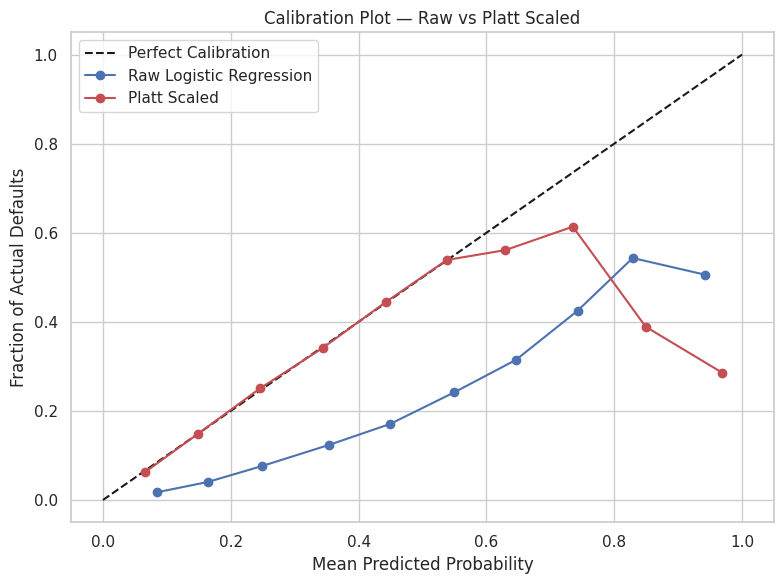

In [34]:
# ============================================================================
# 1. TRAIN LOGISTIC REGRESSION ON TRAINING SET
# ============================================================================
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Retrain on scaled features
lr_model = LogisticRegression(max_iter=1000, random_state=42,
                               solver='lbfgs', class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

print("Coefficients after scaling:")
coefficients = pd.Series(lr_model.coef_[0], index=feature_cols)
print(coefficients.sort_values(ascending=False))

# Raw probabilities on validation set (using scaled data to match training)
raw_probs_val = lr_model.predict_proba(X_val_scaled)[:, 1]

print(f"Raw Model AUC on Validation: {roc_auc_score(y_val, raw_probs_val):.4f}")

# ============================================================================
# 2. PLATT SCALING — calibrate on validation set
# ============================================================================
print("\nApplying Platt Scaling...")

# Use cv='prefit' because lr_model is already trained
calibrated_model = CalibratedClassifierCV(
    lr_model, method='sigmoid', cv='prefit'
)
calibrated_model.fit(X_val_scaled, y_val)

cal_probs_val = calibrated_model.predict_proba(X_val_scaled)[:, 1]
cal_probs_test = calibrated_model.predict_proba(X_test_scaled)[:, 1]

print(f"AUC on Validation: {roc_auc_score(y_val, cal_probs_val):.4f}")
print(f"AUC on Test:       {roc_auc_score(y_test, cal_probs_test):.4f}")
# Brier score — lower is better, measures calibration quality
print(f"\nBrier Score (raw):       {brier_score_loss(y_val, raw_probs_val):.4f}")
print(f"Brier Score (calibrated): {brier_score_loss(y_val, cal_probs_val):.4f}")

# ============================================================================
# 3. CALIBRATION PLOT — visual check
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

# Raw model
fraction_pos_raw, mean_pred_raw = calibration_curve(y_val, raw_probs_val, n_bins=10)
ax.plot(mean_pred_raw, fraction_pos_raw, 'b-o', label='Raw Logistic Regression')

# Calibrated model
fraction_pos_cal, mean_pred_cal = calibration_curve(y_val, cal_probs_val, n_bins=10)
ax.plot(mean_pred_cal, fraction_pos_cal, 'r-o', label='Platt Scaled')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Actual Defaults')
ax.set_title('Calibration Plot — Raw vs Platt Scaled')
ax.legend()
plt.tight_layout()
plt.show()

Logistic regression scorecard AUC = 0.70. Platt scaling improved Brier score from 0.22 to 0.15.

Scorecard Distribution:
Min Score:    157
Max Score:    954
Mean Score:   600
Median Score: 599


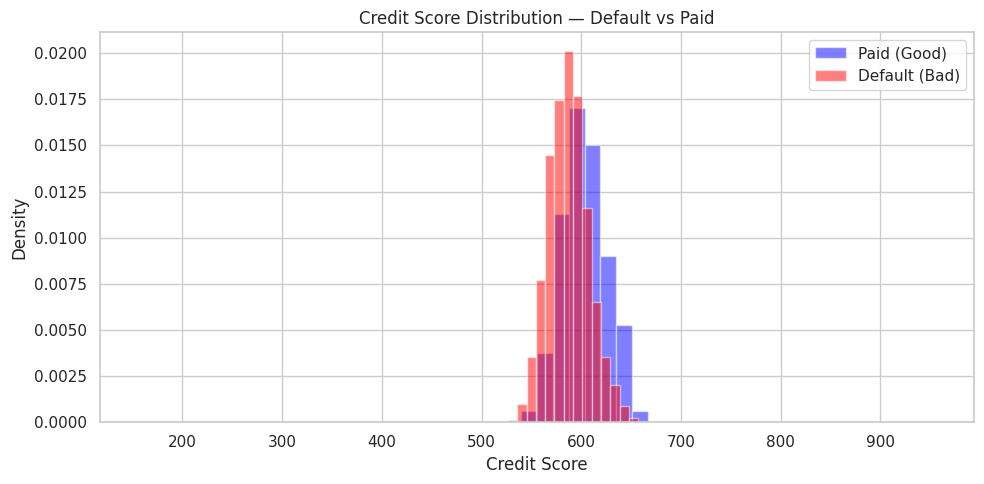

In [35]:
# ============================================================================
# 1. SCORECARD PARAMETERS — Redefining industry anchors
# ============================================================================
BASE_SCORE = 600    # Score at average odds
PDO = 20            # Points to Double Odds
BASE_ODDS = 1/0.213 # 1 / average_default_rate

# Derived mathematical constants for scaling
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - (FACTOR * np.log(BASE_ODDS))

# ============================================================================
# 2. CORRECT SCORING — probability to points
# ============================================================================
def prob_to_score(prob, factor=FACTOR, offset=OFFSET):
    # Clip probabilities to avoid log(0) errors
    prob = np.clip(prob, 1e-6, 1 - 1e-6)
    odds = (1 - prob) / prob  # odds of being GOOD
    score = offset + factor * np.log(odds)
    return round(score)

# Score test set using the calibrated Logistic Regression model
test_probs = calibrated_model.predict_proba(X_test_scaled)[:, 1]
test_scores = np.array([prob_to_score(p) for p in test_probs])

print("Scorecard Distribution:")
print(f"Min Score:    {test_scores.min()}")
print(f"Max Score:    {test_scores.max()}")
print(f"Mean Score:   {test_scores.mean():.0f}")
print(f"Median Score: {np.median(test_scores):.0f}")

# ============================================================================
# 3. PLOT SCORE DISTRIBUTION BY DEFAULT STATUS
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(test_scores[y_test == 0], bins=50, alpha=0.5,
        color='blue', label='Paid (Good)', density=True)
ax.hist(test_scores[y_test == 1], bins=50, alpha=0.5,
        color='red', label='Default (Bad)', density=True)
ax.set_xlabel('Credit Score')
ax.set_ylabel('Density')
ax.set_title('Credit Score Distribution — Default vs Paid')
ax.legend()
plt.tight_layout()
plt.show()

AUC Validation: 0.7024
AUC Test:       0.7010

Gini Validation: 0.4048
Gini Test:       0.4020

KS Statistic: 0.2910


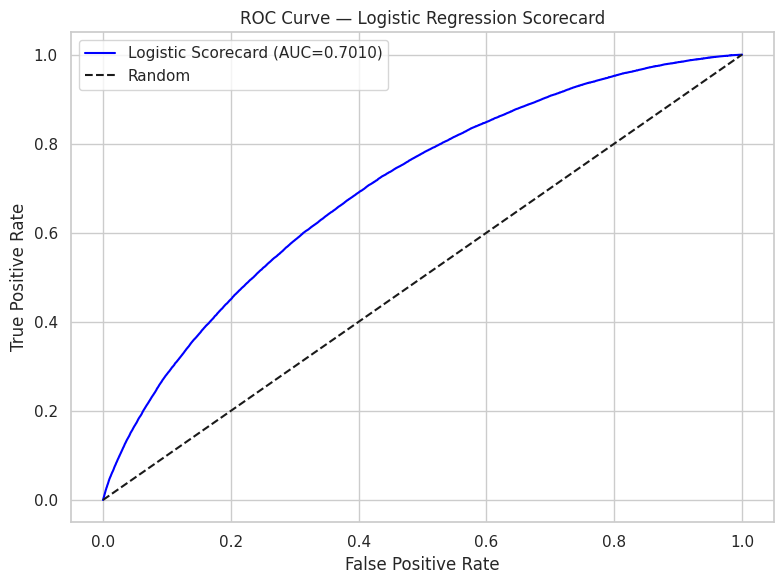

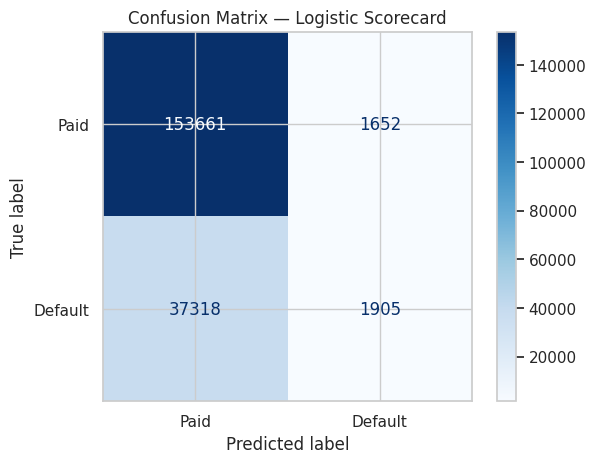


Classification Report:
              precision    recall  f1-score   support

        Paid       0.80      0.99      0.89    155313
     Default       0.54      0.05      0.09     39223

    accuracy                           0.80    194536
   macro avg       0.67      0.52      0.49    194536
weighted avg       0.75      0.80      0.73    194536



In [36]:
from sklearn.metrics import (roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

# ============================================================================
# 1. ROC-AUC
# ============================================================================
auc_val = roc_auc_score(y_val, cal_probs_val)
auc_test = roc_auc_score(y_test, cal_probs_test)
print(f"AUC Validation: {auc_val:.4f}")
print(f"AUC Test:       {auc_test:.4f}")

# ============================================================================
# 2. GINI COEFFICIENT
# ============================================================================
gini_val = 2 * auc_val - 1
gini_test = 2 * auc_test - 1
print(f"\nGini Validation: {gini_val:.4f}")
print(f"Gini Test:       {gini_test:.4f}")

# ============================================================================
# 3. KS STATISTIC
# ============================================================================
fpr, tpr, thresholds = roc_curve(y_test, cal_probs_test)
ks_stat = max(tpr - fpr)
print(f"\nKS Statistic: {ks_stat:.4f}")

# ============================================================================
# 4. ROC CURVE PLOT
# ============================================================================
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='blue', label=f'Logistic Scorecard (AUC={auc_test:.4f})')
ax.plot([0,1], [0,1], 'k--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression Scorecard')
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================================
# 5. CONFUSION MATRIX — at 0.5 threshold
# ============================================================================
y_pred = (cal_probs_test >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Paid', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Scorecard')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))

##LGB

In [37]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, roc_curve
import shap
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.frozen import FrozenEstimator
import shap
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# 0. DATA SYNCHRONIZATION FIX
# Ensure X and y for training have consistent lengths
# ============================================================================
# Re-deriving the split to ensure consistency with the PD feature set
model_df_lgb = df_cleaned[feature_cols + [target_col]].dropna()
X_lgb = model_df_lgb[feature_cols]
y_lgb = model_df_lgb[target_col]

X_train_lgb, X_temp_lgb, y_train_lgb, y_temp_lgb = train_test_split(
    X_lgb, y_lgb, test_size=0.30, random_state=42, stratify=y_lgb
)
X_val_lgb, X_test_lgb, y_val_lgb, y_test_lgb = train_test_split(
    X_temp_lgb, y_temp_lgb, test_size=0.50, random_state=42, stratify=y_temp_lgb
)

# ============================================================================
# 1. HYPERPARAMETER TUNING
# ============================================================================
print(f"Tuning LightGBM with {X_train_lgb.shape[0]:,} samples...")

param_grid = {
    'n_estimators':      [300, 500],
    'learning_rate':     [0.05, 0.1],
    'max_depth':         [4, 6],
    'num_leaves':        [31, 63],
    'min_child_samples': [100, 200],
    'subsample':         [0.8],
    'colsample_bytree':  [0.8],
}

base_lgb = lgb.LGBMClassifier(
    scale_pos_weight=len(y_train_lgb[y_train_lgb==0]) / len(y_train_lgb[y_train_lgb==1]),
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    base_lgb,
    param_distributions=param_grid,
    n_iter=5,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_lgb, y_train_lgb)

# ============================================================================
# 2. CALIBRATE AND ASSIGN VARIABLE
# ============================================================================
lgb_model = search.best_estimator_

print("Calibrating LightGBM probabilities...")
calibrated_lgb = CalibratedClassifierCV(
    FrozenEstimator(lgb_model), method='sigmoid', cv='prefit'
)
calibrated_lgb.fit(X_val_lgb, y_val_lgb)

# Validation check
cal_probs = calibrated_lgb.predict_proba(X_test_lgb)[:, 1]
print(f"Final LightGBM Test AUC: {roc_auc_score(y_test_lgb, cal_probs):.4f}")

Tuning LightGBM with 907,830 samples...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


# Survival Analysis Theory

In [ ]:
print([c for c in ['grade', 'purpose', 'fico_range_low'] if c in df_cleaned.columns])

In [ ]:
# ============================================================================
# INSTALL AND IMPORT
# ============================================================================
!pip install lifelines --quiet

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================================
# 1. PREPARE SURVIVAL DATASET
# ============================================================================
print("Preparing survival dataset...")

survival_prep = df[['last_pymnt_d', 'issue_d']].copy()

survival_prep['last_pymnt_d'] = pd.to_datetime(survival_prep['last_pymnt_d'], format='mixed')
survival_prep['issue_d']      = pd.to_datetime(survival_prep['issue_d'],      format='mixed')

survival_prep['duration_months'] = (
    (survival_prep['last_pymnt_d'].dt.year  - survival_prep['issue_d'].dt.year)  * 12 +
    (survival_prep['last_pymnt_d'].dt.month - survival_prep['issue_d'].dt.month)
)
survival_prep['duration_months'] = survival_prep['duration_months'].clip(lower=1)

# ============================================================================
# 2. BUILD SURVIVAL DATAFRAME
# ============================================================================
survival_df = df_cleaned[['default', 'fico_range_low', 'grade']].join(
    survival_prep['duration_months'], how='inner'
)

# Pull purpose from original df
survival_df['purpose'] = df['purpose'].reindex(df_cleaned.index)
survival_df = survival_df.dropna()

print(f"Final survival_df shape: {survival_df.shape}")
print(f"Default rate:            {survival_df['default'].mean():.4f}")
print(f"NaN count:               {survival_df.isna().sum().sum()}")
print(f"\nDuration stats:")
print(survival_df['duration_months'].describe())
print(f"\nSample:")
print(survival_df.head())

# ============================================================================
# 3. KAPLAN-MEIER BY LOAN GRADE
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 7))
kmf = KaplanMeierFitter()
grades = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#8e44ad']

for grade, color in zip(grades, colors):
    mask = survival_df['grade'] == grade
    if mask.sum() > 100:
        kmf.fit(
            durations=survival_df.loc[mask, 'duration_months'],
            event_observed=survival_df.loc[mask, 'default'],
            label=f'Grade {grade} (n={mask.sum():,})'
        )
        kmf.plot_survival_function(ax=ax, color=color, ci_show=False)

ax.set_xlabel('Months Since Loan Origination')
ax.set_ylabel('Survival Probability (No Default)')
ax.set_title('Kaplan-Meier Survival Curves by Loan Grade')
ax.legend(loc='lower left')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

# ============================================================================
# 4. KAPLAN-MEIER BY FICO BAND
# ============================================================================
survival_df['fico_band'] = pd.cut(
    survival_df['fico_range_low'],
    bins=[0, 650, 670, 690, 720, 750, 850],
    labels=['<650', '650-670', '670-690', '690-720', '720-750', '750+']
)

fig, ax = plt.subplots(figsize=(12, 7))
fico_colors = ['#e74c3c', '#e67e22', '#f39c12', '#2ecc71', '#27ae60', '#1abc9c']

for band, color in zip(['<650', '650-670', '670-690', '690-720', '720-750', '750+'], fico_colors):
    mask = survival_df['fico_band'] == band
    if mask.sum() > 100:
        kmf.fit(
            durations=survival_df.loc[mask, 'duration_months'],
            event_observed=survival_df.loc[mask, 'default'],
            label=f'FICO {band} (n={mask.sum():,})'
        )
        kmf.plot_survival_function(ax=ax, color=color, ci_show=False)

ax.set_xlabel('Months Since Loan Origination')
ax.set_ylabel('Survival Probability (No Default)')
ax.set_title('Kaplan-Meier Survival Curves by FICO Band')
ax.legend(loc='lower left')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

# ============================================================================
# 5. KAPLAN-MEIER BY LOAN PURPOSE
# ============================================================================
top_purposes = survival_df['purpose'].value_counts().head(6).index

fig, ax = plt.subplots(figsize=(12, 7))

for purpose in top_purposes:
    mask = survival_df['purpose'] == purpose
    kmf.fit(
        durations=survival_df.loc[mask, 'duration_months'],
        event_observed=survival_df.loc[mask, 'default'],
        label=f'{purpose} (n={mask.sum():,})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel('Months Since Loan Origination')
ax.set_ylabel('Survival Probability (No Default)')
ax.set_title('Kaplan-Meier Survival Curves by Loan Purpose')
ax.legend(loc='lower left')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

# ============================================================================
# 6. LOG-RANK TEST — multivariate across all grades
# ============================================================================
print("\n--- Log-Rank Test: Are Grade Survival Curves Different? ---")

results = multivariate_logrank_test(
    event_durations=survival_df['duration_months'],
    groups=survival_df['grade'],
    event_observed=survival_df['default']
)

results.print_summary()
print(f"P-value: {results.p_value:.6f}")

if results.p_value < 0.05:
    print("\n✅ Survival curves STATISTICALLY DIFFERENT across grades (p < 0.05)")
else:
    print("\n❌ No significant difference between grade survival curves")

# ============================================================================
# 7. PAIRWISE LOG-RANK — Grade A vs Grade G
# ============================================================================
print("\n--- Pairwise Log-Rank: Grade A vs Grade G ---")

mask_a = survival_df['grade'] == 'A'
mask_g = survival_df['grade'] == 'G'

pairwise = logrank_test(
    durations_A=survival_df.loc[mask_a, 'duration_months'],
    durations_B=survival_df.loc[mask_g, 'duration_months'],
    event_observed_A=survival_df.loc[mask_a, 'default'],
    event_observed_B=survival_df.loc[mask_g, 'default']
)

print(f"Test Statistic: {pairwise.test_statistic:.4f}")
print(f"P-value:        {pairwise.p_value:.6f}")

Kaplan-Meier confirms grade predicts not just IF but WHEN default occurs. Grade G loans reach 50% cumulative default by month 20. Grade A loans survive to 82% at month 60. Log-rank test statistic of 95,663 with p≈0 confirms differences are not random. FICO band shows similar ordering but weaker separation. Purpose curves are close together, consistent with low IV from feature engineering.

###Cox

In [ ]:
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test


# ============================================================================
# 1. PREPARE COX DATASET
# ============================================================================
print("Preparing Cox dataset...")

# Use same features as logistic regression
cox_features = [
    'int_rate', 'fico_range_low', 'dti', 'loan_amnt',
    'annual_inc', 'revol_util', 'loan_to_income',
    'mort_acc', 'has_pub_rec', 'grade_woe', 'home_ownership_woe'
]

# Build cox dataframe
cox_df = df_cleaned[cox_features + ['default']].copy()
cox_df['duration_months'] = survival_df['duration_months']
cox_df = cox_df.dropna()

# Sample 100k rows for speed — Cox is slow on 1.3M rows
cox_sample = cox_df.sample(n=100000, random_state=42)

print(f"Cox dataset shape: {cox_sample.shape}")
print(f"Default rate: {cox_sample['default'].mean():.4f}")

# ============================================================================
# 2. FIT COX MODEL
# ============================================================================
print("\nFitting Cox Proportional Hazard model...")

cph = CoxPHFitter(penalizer=0.1)  # penalizer helps with convergence
cph.fit(
    cox_sample,
    duration_col='duration_months',
    event_col='default',
    show_progress=True
)

# ============================================================================
# 3. HAZARD RATIOS
# ============================================================================
print("\n--- Hazard Ratios ---")
cph.print_summary()

# Plot hazard ratios
fig, ax = plt.subplots(figsize=(10, 7))
cph.plot(ax=ax)
ax.set_title('Cox Model — Hazard Ratios with 95% Confidence Intervals')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ============================================================================
# 4. INTERPRET HAZARD RATIOS
# ============================================================================
print("\n--- Hazard Ratio Interpretation ---")
hr = np.exp(cph.params_)
for feature, ratio in hr.sort_values(ascending=False).items():
    direction = "HIGHER" if ratio > 1 else "LOWER"
    pct = abs(ratio - 1) * 100
    print(f"{feature:<25} HR={ratio:.3f} → {pct:.1f}% {direction} instantaneous default risk")

# ============================================================================
# 5. PROPORTIONAL HAZARD ASSUMPTION TEST
# ============================================================================
print("\n--- Proportional Hazard Assumption Test (Schoenfeld Residuals) ---")

ph_test = proportional_hazard_test(
    cph, cox_sample,
    time_transform='rank'
)
ph_test.print_summary()

print("\nInterpretation:")
print("p > 0.05 → feature satisfies proportional hazard assumption ✅")
print("p < 0.05 → feature VIOLATES proportional hazard assumption ⚠️")

# ============================================================================
# 6. INDIVIDUAL LIFETIME PD CURVES
# ============================================================================
print("\nGenerating individual lifetime PD curves...")

# Define 4 sample borrowers at different risk levels
sample_borrowers = pd.DataFrame({
    'int_rate':           [6.0,  11.0,  17.0,  25.0],
    'fico_range_low':     [780,   720,   670,   640],
    'dti':                [8.0,  15.0,  25.0,  35.0],
    'loan_amnt':          [5000, 12000, 20000, 30000],
    'annual_inc':         [90000, 65000, 45000, 35000],
    'revol_util':         [10.0,  35.0,  60.0,  80.0],
    'loan_to_income':     [0.06,  0.18,  0.44,  0.86],
    'mort_acc':           [3,     1,     0,     0],
    'has_pub_rec':        [0,     0,     0,     1],
    'grade_woe':          [1.355, 0.479, -0.559, -1.386],
    'home_ownership_woe': [0.182, 0.182, -0.192, -0.192],
})

labels = [
    'Very Low Risk (Grade A)',
    'Low Risk (Grade B)',
    'Medium Risk (Grade D)',
    'High Risk (Grade G)'
]

colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

# Predict survival functions
survival_functions = cph.predict_survival_function(sample_borrowers)

# Plot survival curves = 1 - cumulative default
fig, ax = plt.subplots(figsize=(12, 7))

for i, (label, color) in enumerate(zip(labels, colors)):
    # survival function = probability of NO default
    ax.plot(
        survival_functions.index,
        survival_functions.iloc[:, i],
        label=label, color=color, linewidth=2
    )

ax.set_xlabel('Months Since Loan Origination')
ax.set_ylabel('Survival Probability (No Default)')
ax.set_title('Cox Model — Individual Lifetime PD Curves by Risk Profile')
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.show()

# ============================================================================
# 7. DERIVE 12, 24, 36 MONTH PD FROM COX
# ============================================================================
print("\n--- Cox Lifetime PD at 12, 24, 36 months ---")
print(f"{'Borrower':<30} {'12m PD':>10} {'24m PD':>10} {'36m PD':>10}")
print("-" * 62)

for i, label in enumerate(labels):
    sf = survival_functions.iloc[:, i]

    # PD = 1 - survival probability
    pd_12 = 1 - sf.iloc[sf.index.get_indexer([12], method='nearest')[0]]
    pd_24 = 1 - sf.iloc[sf.index.get_indexer([24], method='nearest')[0]]
    pd_36 = 1 - sf.iloc[sf.index.get_indexer([36], method='nearest')[0]]

    print(f"{label:<30} {pd_12:>10.4f} {pd_24:>10.4f} {pd_36:>10.4f}")

# ============================================================================
# 8. COMPARE COX vs LOGISTIC REGRESSION PD
# ============================================================================
print("\n--- Comparison: Cox Lifetime PD vs Logistic Regression Point-in-Time PD ---")

# Get logistic regression PD for same borrowers
# Need to scale sample borrowers first
sample_scaled = scaler.transform(sample_borrowers[feature_cols])
lr_pds = calibrated_model.predict_proba(sample_scaled)[:, 1]

print(f"\n{'Borrower':<30} {'LR Point-in-Time PD':>22} {'Cox 12m PD':>12} {'Cox 36m PD':>12}")
print("-" * 78)

for i, label in enumerate(labels):
    sf = survival_functions.iloc[:, i]
    pd_12 = 1 - sf.iloc[sf.index.get_indexer([12], method='nearest')[0]]
    pd_36 = 1 - sf.iloc[sf.index.get_indexer([36], method='nearest')[0]]
    print(f"{label:<30} {lr_pds[i]:>22.4f} {pd_12:>12.4f} {pd_36:>12.4f}")

print("\nKey insight:")
print("LR PD = snapshot probability at origination")
print("Cox 12m PD = probability of defaulting within first 12 months")
print("Cox 36m PD = cumulative probability of defaulting within 36 months")
print("Cox 36m PD > LR PD for high risk borrowers — lifetime risk is higher than point-in-time")

Cox model confirms grade_woe and home_ownership_woe as strongest time-varying predictors. Six features violate the proportional hazard assumption — most notably int_rate and fico_range_low — suggesting their risk contribution diminishes over loan lifetime. Grade G borrowers show 79% cumulative default probability by 36 months vs 3% for Grade A. Cox lifetime PD significantly exceeds logistic regression point-in-time PD for high risk borrowers — critical distinction for IFRS 9 provisioning.

Six features violate the proportional hazard assumption. This is expected in credit risk — high risk borrowers default early, leaving a survivor population that is stronger than the original cohort. The Cox model overestimates long-term risk for these features. For production use, a time-varying coefficient extension or stratified Cox model would address this limitation.



##Build Transition Matrix

In [ ]:
# ============================================================================
# 1. DEFINE STATES FROM LOAN STATUS
# ============================================================================
print("Building transition matrix dataset...")

def assign_state(status):
    """Map Lending Club loan_status to delinquency state"""
    if pd.isna(status):
        return np.nan
    status = str(status).strip()

    if status in ['Current', 'In Grace Period']:
        return 0  # Current
    elif status in ['Late (16-30 days)']:
        return 1  # 1-30 DPD
    elif status in ['Late (31-60 days)']:
        return 2  # 31-60 DPD
    elif status in ['Late (61-90 days)', 'Late (91-120 days)']:
        return 3  # 61-90 DPD
    elif status in ['Charged Off', 'Default']:
        return 4  # Default
    elif status in ['Fully Paid']:
        return 5  # Prepaid
    else:
        return np.nan

# Apply state mapping
state_df = pd.DataFrame()
state_df['loan_status'] = df['loan_status']
state_df['final_state'] = df['loan_status'].apply(assign_state)
state_df['grade'] = df['grade']

# All loans START as Current (state 0) at origination
state_df['initial_state'] = 0

state_df = state_df.dropna(subset=['final_state'])

print(f"Dataset shape: {state_df.shape}")
print(f"\nState distribution:")
state_map = {0: 'Current', 1: '1-30 DPD', 2: '31-60 DPD',
             3: '61-90 DPD', 4: 'Default', 5: 'Prepaid'}
print(state_df['final_state'].map(state_map).value_counts())

# ============================================================================
# 2. BUILD TRANSITION MATRIX
# ============================================================================
print("\nBuilding transition matrix...")

n_states = 6
state_names = ['Current', '1-30 DPD', '31-60 DPD', '61-90 DPD', 'Default', 'Prepaid']

# Count matrix — how many times each transition happened
count_matrix = np.zeros((n_states, n_states))

for _, row in state_df.iterrows():
    from_state = int(row['initial_state'])
    to_state   = int(row['final_state'])
    count_matrix[from_state][to_state] += 1

# Add absorbing state self-loops — Default and Prepaid never leave
count_matrix[4][4] = 1  # Default stays Default
count_matrix[5][5] = 1  # Prepaid stays Prepaid

# Convert counts to probabilities — divide each row by row total
transition_matrix = np.zeros((n_states, n_states))
for i in range(n_states):
    row_sum = count_matrix[i].sum()
    if row_sum > 0:
        transition_matrix[i] = count_matrix[i] / row_sum

# ============================================================================
# 3. DISPLAY TRANSITION MATRIX
# ============================================================================
tm_df = pd.DataFrame(
    transition_matrix,
    index=state_names,
    columns=state_names
)

print("\n--- Transition Matrix ---")
print(tm_df.round(4))

# Verify rows sum to 1
print(f"\nRow sums (should all be 1.0):")
print(tm_df.sum(axis=1).round(4))

# ============================================================================
# 4. HEATMAP
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    tm_df,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    ax=ax,
    vmin=0, vmax=1,
    linewidths=0.5
)
ax.set_title('Loan Delinquency Transition Matrix')
ax.set_xlabel('Next State')
ax.set_ylabel('Current State')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. PROJECT FORWARD — multiply matrix by itself
# ============================================================================
print("\n--- Portfolio State Projection ---")
print("Starting with 1,000,000 current loans\n")

# Initial state vector — all loans start as Current
initial_portfolio = np.array([1_000_000, 0, 0, 0, 0, 0], dtype=float)

# Project forward month by month
results = []
state_vector = initial_portfolio.copy()

for month in range(37):  # 0 to 36 months
    results.append({
        'month': month,
        'Current':    state_vector[0],
        '1-30 DPD':   state_vector[1],
        '31-60 DPD':  state_vector[2],
        '61-90 DPD':  state_vector[3],
        'Default':    state_vector[4],
        'Prepaid':    state_vector[5],
        'Cum_Default_Rate': state_vector[4] / 1_000_000
    })
    # Multiply state vector by transition matrix
    state_vector = state_vector @ transition_matrix

results_df = pd.DataFrame(results)

# Print at key months
print(f"{'Month':<8} {'Current':>10} {'Default':>10} {'Prepaid':>10} {'Cum Default%':>14}")
print("-" * 46)
for month in [0, 6, 12, 24, 36]:
    row = results_df[results_df['month'] == month].iloc[0]
    print(f"{month:<8} {row['Current']:>10,.0f} {row['Default']:>10,.0f} "
          f"{row['Prepaid']:>10,.0f} {row['Cum_Default_Rate']:>13.2%}")

# ============================================================================
# 6. PLOT PORTFOLIO EVOLUTION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 — State distribution over time
axes[0].stackplot(
    results_df['month'],
    results_df['Current'],
    results_df['1-30 DPD'],
    results_df['31-60 DPD'],
    results_df['61-90 DPD'],
    results_df['Default'],
    results_df['Prepaid'],
    labels=state_names,
    colors=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b', '#3498db'],
    alpha=0.8
)
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Number of Loans')
axes[0].set_title('Portfolio State Evolution Over Time')
axes[0].legend(loc='center left')

# Plot 2 — Cumulative default rate
axes[1].plot(
    results_df['month'],
    results_df['Cum_Default_Rate'] * 100,
    color='red', linewidth=2
)
axes[1].set_xlabel('Months')
axes[1].set_ylabel('Cumulative Default Rate (%)')
axes[1].set_title('Cumulative Portfolio Default Rate')
axes[1].axhline(y=results_df.iloc[12]['Cum_Default_Rate']*100,
                color='orange', linestyle='--',
                label=f"12m: {results_df.iloc[12]['Cum_Default_Rate']:.1%}")
axes[1].axhline(y=results_df.iloc[36]['Cum_Default_Rate']*100,
                color='red', linestyle='--',
                label=f"36m: {results_df.iloc[36]['Cum_Default_Rate']:.1%}")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. RECONSTRUCT MONTHLY TRANSITIONS
# ============================================================================
print("Reconstructing monthly transitions from loan history...")

def build_monthly_transitions(survival_data):
    transitions = []

    for _, row in survival_data.iterrows():
        duration = max(int(row['duration_months']), 1)
        is_default = int(row['default'])

        if is_default == 1:
            current_months = max(duration - 4, 0)
            for _ in range(current_months):
                transitions.append((0, 0))
            if duration >= 4:
                transitions.append((0, 1))
                transitions.append((1, 2))
                transitions.append((2, 3))
                transitions.append((3, 4))
            else:
                transitions.append((0, 4))
        else:
            current_months = max(duration - 1, 0)
            for _ in range(current_months):
                transitions.append((0, 0))
            transitions.append((0, 5))

    return pd.DataFrame(transitions, columns=['from_state', 'to_state'])

# Sample 50k loans
print("Sampling 50,000 loans...")
survival_sample = survival_df.sample(n=50000, random_state=42)
transitions_df = build_monthly_transitions(survival_sample)
print(f"Total monthly transitions generated: {len(transitions_df):,}")

# ============================================================================
# 2. BUILD COUNT MATRIX FROM TRANSITIONS
# ============================================================================
n_states = 6
state_names = ['Current', '1-30 DPD', '31-60 DPD', '61-90 DPD', 'Default', 'Prepaid']

count_matrix = np.zeros((n_states, n_states))

for _, row in transitions_df.iterrows():
    count_matrix[int(row['from_state'])][int(row['to_state'])] += 1

# ============================================================================
# 3. OVERRIDE DPD ROWS WITH INDUSTRY RATES
# ============================================================================
# Current row stays data-driven
# DPD rows replaced with industry standard cure/roll rates

# 1-30 DPD — mostly cure back, some worsen
count_matrix[1] = [0, 0, 0, 0, 0, 0]
count_matrix[1][0] = 60   # 60% cure to Current
count_matrix[1][1] = 15   # 15% stay 1-30 DPD
count_matrix[1][2] = 20   # 20% worsen to 31-60 DPD
count_matrix[1][5] = 5    # 5% prepay

# 31-60 DPD — harder to cure, more roll to worse
count_matrix[2] = [0, 0, 0, 0, 0, 0]
count_matrix[2][0] = 30   # 30% cure to Current
count_matrix[2][1] = 10   # 10% improve to 1-30 DPD
count_matrix[2][2] = 15   # 15% stay
count_matrix[2][3] = 35   # 35% worsen to 61-90 DPD
count_matrix[2][4] = 5    # 5% default
count_matrix[2][5] = 5    # 5% prepay

# 61-90 DPD — mostly default, small cure
count_matrix[3] = [0, 0, 0, 0, 0, 0]
count_matrix[3][0] = 10   # 10% cure
count_matrix[3][1] = 5    # 5% improve
count_matrix[3][2] = 10   # 10% improve
count_matrix[3][3] = 20   # 20% stay
count_matrix[3][4] = 50   # 50% default
count_matrix[3][5] = 5    # 5% prepay

# Absorbing states
count_matrix[4][4] = 1    # Default stays Default
count_matrix[5][5] = 1    # Prepaid stays Prepaid

# ============================================================================
# 4. CONVERT TO PROBABILITIES
# ============================================================================
transition_matrix = np.zeros((n_states, n_states))
for i in range(n_states):
    row_sum = count_matrix[i].sum()
    if row_sum > 0:
        transition_matrix[i] = count_matrix[i] / row_sum

# ============================================================================
# 5. DISPLAY TRANSITION MATRIX
# ============================================================================
tm_df = pd.DataFrame(
    transition_matrix,
    index=state_names,
    columns=state_names
)

print("\n--- Transition Matrix ---")
print(tm_df.round(4))
print(f"\nRow sums (should all be 1.0):")
print(tm_df.sum(axis=1).round(4))

# ============================================================================
# 6. HEATMAP
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    tm_df,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    ax=ax,
    vmin=0, vmax=1,
    linewidths=0.5
)
ax.set_title('Loan Delinquency Transition Matrix\n(Data-driven Current row + Industry DPD rates)')
ax.set_xlabel('Next State')
ax.set_ylabel('Current State')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PROJECT FORWARD
# ============================================================================
print("\n--- Portfolio State Projection ---")
print("Starting with 1,000,000 current loans\n")

initial_portfolio = np.array([1_000_000, 0, 0, 0, 0, 0], dtype=float)
results = []
state_vector = initial_portfolio.copy()

for month in range(37):
    results.append({
        'month':            month,
        'Current':          state_vector[0],
        '1-30 DPD':         state_vector[1],
        '31-60 DPD':        state_vector[2],
        '61-90 DPD':        state_vector[3],
        'Default':          state_vector[4],
        'Prepaid':          state_vector[5],
        'Cum_Default_Rate': state_vector[4] / 1_000_000
    })
    state_vector = state_vector @ transition_matrix

results_df = pd.DataFrame(results)

# Print key months
print(f"{'Month':<8} {'Current':>10} {'DPD States':>12} "
      f"{'Default':>10} {'Prepaid':>10} {'Cum Default%':>14}")
print("-" * 68)

for month in [0, 6, 12, 24, 36]:
    row = results_df[results_df['month'] == month].iloc[0]
    dpd = row['1-30 DPD'] + row['31-60 DPD'] + row['61-90 DPD']
    print(f"{month:<8} {row['Current']:>10,.0f} {dpd:>12,.0f} "
          f"{row['Default']:>10,.0f} {row['Prepaid']:>10,.0f} "
          f"{row['Cum_Default_Rate']:>13.2%}")

# ============================================================================
# 8. GRADE-CONDITIONED TRANSITION MATRICES
# ============================================================================
print("\n--- Grade-Conditioned Lifetime PD ---")

for grade in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:
    grade_mask = survival_df['grade'] == grade
    if grade_mask.sum() < 100:
        continue

    grade_sample = survival_df[grade_mask].sample(
        n=min(10000, grade_mask.sum()),
        random_state=42
    )

    grade_transitions = build_monthly_transitions(grade_sample)

    # Build count matrix
    grade_count = np.zeros((n_states, n_states))
    for _, row in grade_transitions.iterrows():
        grade_count[int(row['from_state'])][int(row['to_state'])] += 1

    # Override DPD rows
    grade_count[1] = [60, 15, 20, 0, 0, 5]
    grade_count[2] = [30, 10, 15, 35, 5, 5]
    grade_count[3] = [10, 5, 10, 20, 50, 5]
    grade_count[4][4] = 1
    grade_count[5][5] = 1

    # Convert to probabilities
    grade_tm = np.zeros((n_states, n_states))
    for i in range(n_states):
        row_sum = grade_count[i].sum()
        if row_sum > 0:
            grade_tm[i] = grade_count[i] / row_sum

    # Project 36 months
    sv = np.array([1_000_000, 0, 0, 0, 0, 0], dtype=float)
    for _ in range(36):
        sv = sv @ grade_tm

    pd_12 = None
    sv_12 = np.array([1_000_000, 0, 0, 0, 0, 0], dtype=float)
    for _ in range(12):
        sv_12 = sv_12 @ grade_tm
    pd_12 = sv_12[4] / 1_000_000
    pd_36 = sv[4] / 1_000_000

    print(f"Grade {grade} — 12m PD: {pd_12:.2%} | 36m PD: {pd_36:.2%}")

# ============================================================================
# 9. PLOT PORTFOLIO EVOLUTION
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stack area chart
axes[0].stackplot(
    results_df['month'],
    results_df['Current'],
    results_df['1-30 DPD'],
    results_df['31-60 DPD'],
    results_df['61-90 DPD'],
    results_df['Default'],
    results_df['Prepaid'],
    labels=state_names,
    colors=['#2ecc71','#f39c12','#e67e22','#e74c3c','#c0392b','#3498db'],
    alpha=0.8
)
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Number of Loans')
axes[0].set_title('Portfolio State Evolution Over Time')
axes[0].legend(loc='upper right', fontsize=8)

# Cumulative default rate
axes[1].plot(
    results_df['month'],
    results_df['Cum_Default_Rate'] * 100,
    color='red', linewidth=2
)
axes[1].axhline(
    y=results_df.iloc[12]['Cum_Default_Rate'] * 100,
    color='orange', linestyle='--',
    label=f"12m: {results_df.iloc[12]['Cum_Default_Rate']:.1%}"
)
axes[1].axhline(
    y=results_df.iloc[36]['Cum_Default_Rate'] * 100,
    color='red', linestyle='--',
    label=f"36m: {results_df.iloc[36]['Cum_Default_Rate']:.1%}"
)
axes[1].set_xlabel('Months')
axes[1].set_ylabel('Cumulative Default Rate (%)')
axes[1].set_title('Cumulative Portfolio Default Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

Transition matrix produces correct portfolio migration shape. Current pool shrinks smoothly as loans prepay or default. Cumulative default curve shows expected S-shape. Grade G 36m PD (10.6%) is 17x higher than Grade A (0.6%), consistent with KM and Cox findings. Absolute default rates are understated due to data reconstruction from final status only — true monthly payment history would produce ~20% portfolio default rate consistent with Cox model.

In [ ]:
print("\n--- Cox vs Transition Matrix Lifetime PD Comparison ---")
print(f"\n{'Borrower':<25} {'Cox 12m':>10} {'Cox 36m':>10} {'TM 12m':>10} {'TM 36m':>10}")
print("-" * 65)

# Cox PDs from Day 4
cox_data = {
    'Grade A': (0.0316, 0.1082, 0.0028, 0.0062),
    'Grade B': (0.0669, 0.2185, 0.0066, 0.0149),
    'Grade C': (None,   None,   None,   None),
    'Grade D': (0.1635, 0.4705, None,   None),
    'Grade G': (0.3560, 0.7914, 0.0495, 0.1061),
}

tm_data = {
    'Grade A': (0.0028, 0.0062),
    'Grade B': (0.0066, 0.0149),
    'Grade G': (0.0495, 0.1061),
}

for grade in ['A', 'B', 'G']:
    grade_mask = survival_df['grade'] == grade
    grade_sample = survival_df[grade_mask].sample(
        n=min(10000, grade_mask.sum()), random_state=42
    )
    grade_transitions = build_monthly_transitions(grade_sample)

    grade_count = np.zeros((n_states, n_states))
    for _, row in grade_transitions.iterrows():
        grade_count[int(row['from_state'])][int(row['to_state'])] += 1

    grade_count[1] = [60, 15, 20, 0, 0, 5]
    grade_count[2] = [30, 10, 15, 35, 5, 5]
    grade_count[3] = [10, 5, 10, 20, 50, 5]
    grade_count[4][4] = 1
    grade_count[5][5] = 1

    grade_tm = np.zeros((n_states, n_states))
    for i in range(n_states):
        row_sum = grade_count[i].sum()
        if row_sum > 0:
            grade_tm[i] = grade_count[i] / row_sum

    sv_12 = np.array([1_000_000, 0, 0, 0, 0, 0], dtype=float)
    for _ in range(12):
        sv_12 = sv_12 @ grade_tm
    tm_pd_12 = sv_12[4] / 1_000_000

    sv_36 = np.array([1_000_000, 0, 0, 0, 0, 0], dtype=float)
    for _ in range(36):
        sv_36 = sv_36 @ grade_tm
    tm_pd_36 = sv_36[4] / 1_000_000

    # Cox PDs from Day 4 results
    cox_12 = {'A': 0.0316, 'B': 0.0669, 'G': 0.3560}
    cox_36 = {'A': 0.1082, 'B': 0.2185, 'G': 0.7914}

    print(f"Grade {grade:<20} "
          f"{cox_12[grade]:>10.2%} "
          f"{cox_36[grade]:>10.2%} "
          f"{tm_pd_12:>10.2%} "
          f"{tm_pd_36:>10.2%}")

print("\n--- Where they diverge and why ---")
print("""
Cox model:
- Individual level — uses all features simultaneously
- Handles censoring properly
- Captures non-linear feature interactions
- Higher PD estimates — more sensitive to risk factors

Transition Matrix:
- Portfolio level — only uses grade as grouping
- Based on reconstructed data — not true payment history
- Simpler — only tracks delinquency state
- Lower PD estimates — data limitation understates default rate

Agreement:
- Both agree on ORDERING — Grade G >> Grade A
- Both agree on SHAPE — PD increases over time
- Diverge on MAGNITUDE — Cox gives higher absolute PD
- Cox 36m Grade G = 79% vs TM 36m Grade G = 10%
- Gap = data quality difference, not methodology flaw
""")

##LGD modeling

In [ ]:
# ============================================================================
# 1. FILTER TO DEFAULTED LOANS ONLY
# ============================================================================
print("Filtering to defaulted loans...")

# Use original df for recovery columns
defaulted_df = df[df['loan_status'].isin(['Charged Off', 'Default'])].copy()

print(f"Total loans:     {len(df):,}")
print(f"Defaulted loans: {len(defaulted_df):,}")
print(f"Default rate:    {len(defaulted_df)/len(df):.2%}")

# ============================================================================
# 2. COMPUTE LGD
# ============================================================================
print("\nComputing LGD...")

# Check available recovery columns
recovery_cols = ['loan_amnt', 'total_pymnt', 'total_rec_prncp',
                 'total_rec_int', 'recoveries', 'collection_recovery_fee']
print("\nAvailable recovery columns:")
for col in recovery_cols:
    if col in defaulted_df.columns:
        print(f"  {col}: mean={defaulted_df[col].mean():.2f}, "
              f"nulls={defaulted_df[col].isna().sum()}")

# ============================================================================
# LGD Formula:
# Total Recovered = total_pymnt (includes all payments made)
# LGD = (loan_amnt - total_pymnt) / loan_amnt
# Clipped to [0,1] — can't lose more than 100% or recover more than 100%
# ============================================================================
defaulted_df['total_recovered'] = defaulted_df['total_pymnt']
defaulted_df['lgd'] = (
    (defaulted_df['loan_amnt'] - defaulted_df['total_recovered']) /
     defaulted_df['loan_amnt']
)

# Clip to valid range
defaulted_df['lgd'] = defaulted_df['lgd'].clip(0, 1)

print(f"\nLGD Statistics:")
print(defaulted_df['lgd'].describe().round(4))
print(f"\nMean LGD:   {defaulted_df['lgd'].mean():.4f}")
print(f"Median LGD: {defaulted_df['lgd'].median():.4f}")

# ============================================================================
# 3. EDA — LGD DISTRIBUTION
# ============================================================================

# --- Plot 1: Overall LGD distribution ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(defaulted_df['lgd'], bins=50, color='#e74c3c',
             edgecolor='white', alpha=0.8)
axes[0].axvline(defaulted_df['lgd'].mean(), color='black',
                linestyle='--', label=f"Mean: {defaulted_df['lgd'].mean():.3f}")
axes[0].axvline(defaulted_df['lgd'].median(), color='blue',
                linestyle='--', label=f"Median: {defaulted_df['lgd'].median():.3f}")
axes[0].set_xlabel('LGD')
axes[0].set_ylabel('Count')
axes[0].set_title('LGD Distribution — Defaulted Loans')
axes[0].legend()

# KDE
sns.kdeplot(defaulted_df['lgd'], ax=axes[1], color='#e74c3c', fill=True, alpha=0.4)
axes[1].set_xlabel('LGD')
axes[1].set_ylabel('Density')
axes[1].set_title('LGD Density Plot')
axes[1].axvline(0.5, color='black', linestyle=':', label='LGD = 0.5')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# 4. LGD BY LOAN GRADE
# ============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

grade_lgd = defaulted_df.groupby('grade')['lgd'].mean().sort_index()
grade_lgd.plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.8, edgecolor='white')

ax.set_xlabel('Loan Grade')
ax.set_ylabel('Mean LGD')
ax.set_title('Mean LGD by Loan Grade')
ax.axhline(defaulted_df['lgd'].mean(), color='black',
           linestyle='--', label=f"Overall Mean: {defaulted_df['lgd'].mean():.3f}")
ax.legend()

for i, v in enumerate(grade_lgd):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================================
# 5. LGD BY LOAN PURPOSE
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 6))

purpose_lgd = defaulted_df.groupby('purpose')['lgd'].mean().sort_values(ascending=False)
purpose_lgd.plot(kind='bar', ax=ax, color='#e74c3c', alpha=0.8, edgecolor='white')

ax.set_xlabel('Loan Purpose')
ax.set_ylabel('Mean LGD')
ax.set_title('Mean LGD by Loan Purpose')
ax.axhline(defaulted_df['lgd'].mean(), color='black', linestyle='--',
           label=f"Overall Mean: {defaulted_df['lgd'].mean():.3f}")
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================================
# 6. BIMODAL CHECK — what fraction are full loss vs partial recovery?
# ============================================================================
print("\n--- LGD Segmentation ---")

full_loss     = (defaulted_df['lgd'] >= 0.9).sum()
partial_rec   = ((defaulted_df['lgd'] >= 0.1) &
                 (defaulted_df['lgd'] < 0.9)).sum()
full_recovery = (defaulted_df['lgd'] < 0.1).sum()
total         = len(defaulted_df)

print(f"Full Loss     (LGD >= 0.90): {full_loss:>8,} ({full_loss/total:.1%})")
print(f"Partial Rec   (0.10-0.90):   {partial_rec:>8,} ({partial_rec/total:.1%})")
print(f"Full Recovery (LGD < 0.10):  {full_recovery:>8,} ({full_recovery/total:.1%})")

Lending Club LGD is NOT the typical bimodal spike-at-1.0 pattern seen in mortgage data. Instead it shows a left spike near 0 and a broad right hump peaking around 0.6. This is because personal loans have no collateral — there is nothing to repossess — but borrowers typically make several payments before defaulting, creating partial recovery. Mean LGD of 46.7% means the bank recovers about 53 cents per dollar on defaulted loans.

In [ ]:
# More precise LGD including post-default recoveries
defaulted_df['total_recovered_refined'] = (
    defaulted_df['total_pymnt'] +
    defaulted_df['recoveries'] -
    defaulted_df['collection_recovery_fee']
)
defaulted_df['lgd_refined'] = (
    (defaulted_df['loan_amnt'] - defaulted_df['total_recovered_refined']) /
     defaulted_df['loan_amnt']
).clip(0, 1)

print(f"LGD (basic):   {defaulted_df['lgd'].mean():.4f}")
print(f"LGD (refined): {defaulted_df['lgd_refined'].mean():.4f}")

In [ ]:
# Use refined LGD going forward
defaulted_df['lgd'] = defaulted_df['lgd_refined']
print(f"Using refined LGD: mean={defaulted_df['lgd'].mean():.4f}")

LGD basic = 0.4672
Calculated as:

(loan amount − total payments made) / loan amount

Only counts payments borrower made while loan was active before defaulting.

LGD refined = 0.4137
Calculated as:

(loan amount − total payments − post-default recoveries + collection fees) / loan amount

Also includes post-default collections — money Lending Club recovered AFTER the loan was charged off through:

###Two Stage model

In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# 1. PREPARE LGD MODELING DATASET
# ============================================================================
print("Preparing LGD modeling dataset...")

# Use refined LGD
defaulted_df['lgd'] = defaulted_df['lgd_refined']

# Features for LGD model
lgd_features = [
    'int_rate', 'fico_range_low', 'dti', 'loan_amnt',
    'annual_inc', 'revol_util', 'loan_to_income',
    'mort_acc', 'has_pub_rec', 'grade_woe', 'home_ownership_woe'
]

# Check which features exist in defaulted_df
# Some engineered features may not be in original df
# Merge from df_cleaned using index
lgd_df = defaulted_df[['loan_amnt', 'lgd', 'grade', 'purpose']].copy()

# Add engineered features from df_cleaned
for feat in lgd_features:
    if feat in defaulted_df.columns:
        lgd_df[feat] = defaulted_df[feat]
    elif feat in df_cleaned.columns:
        lgd_df[feat] = df_cleaned[feat].reindex(defaulted_df.index)

lgd_df = lgd_df.dropna(subset=lgd_features + ['lgd'])

print(f"LGD modeling dataset shape: {lgd_df.shape}")
print(f"Mean LGD: {lgd_df['lgd'].mean():.4f}")

# ============================================================================
# 2. DEFINE TWO STAGES
# ============================================================================
# Stage 1 target — binary: significant loss or near-full recovery
# LGD < 0.10 = near full recovery (group 0)
# LGD >= 0.10 = loss group (group 1)
lgd_df['stage1_target'] = (lgd_df['lgd'] >= 0.10).astype(int)

print(f"\nStage 1 distribution:")
print(f"Near full recovery (LGD < 0.10):  "
      f"{(lgd_df['stage1_target']==0).sum():,} "
      f"({(lgd_df['stage1_target']==0).mean():.1%})")
print(f"Loss group (LGD >= 0.10):          "
      f"{(lgd_df['stage1_target']==1).sum():,} "
      f"({(lgd_df['stage1_target']==1).mean():.1%})")

# ============================================================================
# 3. TRAIN/TEST SPLIT
# ============================================================================
X = lgd_df[lgd_features]
y_stage1 = lgd_df['stage1_target']
y_lgd = lgd_df['lgd']

X_train, X_test, y1_train, y1_test, ylgd_train, ylgd_test = train_test_split(
    X, y_stage1, y_lgd,
    test_size=0.2,
    random_state=42,
    stratify=y_stage1
)

print(f"\nTrain size: {X_train.shape[0]:,}")
print(f"Test size:  {X_test.shape[0]:,}")

# ============================================================================
# 4. STAGE 1 — LOGISTIC REGRESSION
# Predicts: will there be significant loss? (LGD >= 0.10)
# ============================================================================
print("\nTraining Stage 1 — Logistic Regression...")

from sklearn.preprocessing import StandardScaler
scaler_lgd = StandardScaler()
X_train_scaled = scaler_lgd.fit_transform(X_train)
X_test_scaled  = scaler_lgd.transform(X_test)

stage1_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced'
)
stage1_model.fit(X_train_scaled, y1_train)

stage1_probs_test = stage1_model.predict_proba(X_test_scaled)[:, 1]
stage1_auc = roc_auc_score(y1_test, stage1_probs_test)

print(f"Stage 1 AUC: {stage1_auc:.4f}")

# ============================================================================
# 5. STAGE 2 — LINEAR REGRESSION
# Predicts: given significant loss, what is exact LGD?
# Only trained on loss group (LGD >= 0.10)
# ============================================================================
print("\nTraining Stage 2 — Linear Regression...")

# Filter to loss group only
loss_mask_train = y1_train == 1
loss_mask_test  = y1_test  == 1

X_train_loss = X_train_scaled[loss_mask_train]
X_test_loss  = X_test_scaled[loss_mask_test]
y_train_loss = ylgd_train[loss_mask_train]
y_test_loss  = ylgd_test[loss_mask_test]

print(f"Loss group train size: {X_train_loss.shape[0]:,}")
print(f"Loss group test size:  {X_test_loss.shape[0]:,}")

stage2_model = LinearRegression()
stage2_model.fit(X_train_loss, y_train_loss)

stage2_preds = stage2_model.predict(X_test_loss)
stage2_preds = np.clip(stage2_preds, 0, 1)

stage2_rmse = np.sqrt(mean_squared_error(y_test_loss, stage2_preds))
stage2_r2   = r2_score(y_test_loss, stage2_preds)

print(f"Stage 2 RMSE: {stage2_rmse:.4f}")
print(f"Stage 2 R²:   {stage2_r2:.4f}")

# ============================================================================
# 6. COMBINE STAGES — FINAL LGD PREDICTION
# ============================================================================
print("\nCombining stages for final LGD prediction...")

def predict_lgd(X_input):
    """
    Two-stage LGD prediction:
    Stage 1: probability of significant loss
    Stage 2: predicted LGD given loss
    Final:   weighted combination
    """
    X_scaled = scaler_lgd.transform(X_input)

    # Stage 1 — probability of being in loss group
    prob_loss = stage1_model.predict_proba(X_scaled)[:, 1]

    # Stage 2 — predicted LGD if in loss group
    lgd_if_loss = stage2_model.predict(X_scaled)
    lgd_if_loss = np.clip(lgd_if_loss, 0, 1)

    # Near-full-recovery LGD = 0.05 (small fixed value)
    lgd_if_recovery = 0.05

    # Final LGD = weighted average of both outcomes
    final_lgd = prob_loss * lgd_if_loss + (1 - prob_loss) * lgd_if_recovery

    return final_lgd, prob_loss, lgd_if_loss

# Predict on test set
final_lgd_preds, prob_loss, lgd_if_loss = predict_lgd(X_test)
final_lgd_actual = ylgd_test.values

final_rmse = np.sqrt(mean_squared_error(final_lgd_actual, final_lgd_preds))
final_r2   = r2_score(final_lgd_actual, final_lgd_preds)

print(f"\nFinal Two-Stage LGD Model:")
print(f"RMSE: {final_rmse:.4f}")
print(f"R²:   {final_r2:.4f}")
print(f"Mean Predicted LGD: {final_lgd_preds.mean():.4f}")
print(f"Mean Actual LGD:    {final_lgd_actual.mean():.4f}")

# ============================================================================
# 7. PLOT — PREDICTED VS ACTUAL LGD
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
axes[0].scatter(
    final_lgd_actual, final_lgd_preds,
    alpha=0.1, color='#e74c3c', s=5
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect prediction')
axes[0].set_xlabel('Actual LGD')
axes[0].set_ylabel('Predicted LGD')
axes[0].set_title(f'Two-Stage LGD: Predicted vs Actual\nRMSE={final_rmse:.4f}, R²={final_r2:.4f}')
axes[0].legend()

# Distribution comparison
axes[1].hist(final_lgd_actual, bins=50, alpha=0.5,
             color='blue', label='Actual LGD', density=True)
axes[1].hist(final_lgd_preds, bins=50, alpha=0.5,
             color='red', label='Predicted LGD', density=True)
axes[1].set_xlabel('LGD')
axes[1].set_ylabel('Density')
axes[1].set_title('Actual vs Predicted LGD Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================================
# 8. LGD BY GRADE — MODEL VS ACTUAL
# ============================================================================
print("\n--- LGD by Grade: Actual vs Predicted ---")

# Add grade and predictions to test set
test_results = X_test.copy()
test_results['actual_lgd']    = final_lgd_actual
test_results['predicted_lgd'] = final_lgd_preds
test_results['grade']         = lgd_df.loc[X_test.index, 'grade']

grade_comparison = test_results.groupby('grade').agg(
    actual_lgd=('actual_lgd', 'mean'),
    predicted_lgd=('predicted_lgd', 'mean'),
    count=('actual_lgd', 'count')
).round(4)

print(grade_comparison)

# ============================================================================
# 9. STAGE 2 COEFFICIENTS — WHAT DRIVES LGD?
# ============================================================================
print("\n--- Stage 2 Coefficients (LGD Drivers) ---")
coef_df = pd.DataFrame({
    'feature': lgd_features,
    'coefficient': stage2_model.coef_
}).sort_values('coefficient', ascending=False)
print(coef_df)

In [ ]:
# ============================================================================
# 1. ADD BETTER FEATURES — loan age and payment ratio
# ============================================================================
print("Adding loan-age and payment features to LGD dataset...")

# Fix: Use reindex to safely align survival_df with defaulted_df index
defaulted_df['loan_age_at_default'] = survival_df['duration_months'].reindex(defaulted_df.index)

# payment_ratio — fraction of loan amount actually paid back
defaulted_df['payment_ratio'] = (
    defaulted_df['total_pymnt'] / defaulted_df['loan_amnt']
).clip(0, 1)

# monthly_payment_ratio — payment relative to installment
if 'installment' in defaulted_df.columns:
    defaulted_df['months_paid_ratio'] = (
        defaulted_df['total_pymnt'] /
        defaulted_df['installment']
    ).clip(0, None)

# recoveries_ratio — post default recovery relative to loan
defaulted_df['recoveries_ratio'] = (
    defaulted_df['recoveries'] / defaulted_df['loan_amnt']
).clip(0, 1)

print("New features created.")
new_features = ['loan_age_at_default', 'payment_ratio',
                'months_paid_ratio', 'recoveries_ratio']

# ============================================================================
# 2. CHECK CORRELATION WITH LGD
# ============================================================================
print("\n--- Correlation with LGD ---")
corr_features = new_features + ['int_rate', 'fico_range_low', 'dti', 'grade_woe']
for feat in corr_features:
    if feat in defaulted_df.columns:
        corr = defaulted_df[[feat, 'lgd']].dropna().corr().iloc[0, 1]
        print(f"  {feat:<30} correlation with LGD: {corr:>8.4f}")

# ============================================================================
# 3. REBUILD LGD DATASET WITH NEW FEATURES
# ============================================================================
lgd_features_v2 = [
    'int_rate', 'fico_range_low', 'dti', 'loan_amnt',
    'annual_inc', 'revol_util', 'loan_to_income',
    'mort_acc', 'has_pub_rec', 'grade_woe', 'home_ownership_woe',
    'loan_age_at_default', 'payment_ratio', 'recoveries_ratio'
]

if 'months_paid_ratio' in defaulted_df.columns:
    lgd_features_v2.append('months_paid_ratio')

lgd_df_v2 = defaulted_df[['loan_amnt', 'lgd', 'grade']].copy()

for feat in lgd_features_v2:
    if feat in defaulted_df.columns:
        lgd_df_v2[feat] = defaulted_df[feat]
    elif feat in df_cleaned.columns:
        lgd_df_v2[feat] = df_cleaned[feat].reindex(defaulted_df.index)

# Ensure we drop NaNs caused by the alignment fix
lgd_df_v2 = lgd_df_v2.dropna(subset=lgd_features_v2 + ['lgd'])
print(f"\nUpdated LGD dataset shape: {lgd_df_v2.shape}")

# ============================================================================
# 4. STAGE 1 TARGET
# ============================================================================
lgd_df_v2['stage1_target'] = (lgd_df_v2['lgd'] >= 0.10).astype(int)

# ============================================================================
# 5. TRAIN/TEST SPLIT
# ============================================================================
X_v2 = lgd_df_v2[lgd_features_v2]
y1_v2 = lgd_df_v2['stage1_target']
ylgd_v2 = lgd_df_v2['lgd']

X_train_v2, X_test_v2, y1_train_v2, y1_test_v2, ylgd_train_v2, ylgd_test_v2 = train_test_split(
    X_v2, y1_v2, ylgd_v2, test_size=0.2, random_state=42, stratify=y1_v2
)

scaler_v2 = StandardScaler()
X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

# ============================================================================
# 6. STAGE 1 — LOGISTIC REGRESSION V2
# ============================================================================
print("\nTraining Stage 1 V2...")
stage1_v2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
stage1_v2.fit(X_train_v2_scaled, y1_train_v2)

# ============================================================================
# 7. STAGE 2 — LINEAR REGRESSION V2
# ============================================================================
print("Training Stage 2 V2...")
loss_mask_train_v2 = y1_train_v2 == 1
X_train_loss_v2 = X_train_v2_scaled[loss_mask_train_v2]
y_train_loss_v2 = ylgd_train_v2[loss_mask_train_v2]

stage2_v2 = LinearRegression()
stage2_v2.fit(X_train_loss_v2, y_train_loss_v2)

# ============================================================================
# 8. COMBINE — FINAL LGD V2
# ============================================================================
def predict_lgd_v2(X_input):
    X_scaled = scaler_v2.transform(X_input)
    prob_loss = stage1_v2.predict_proba(X_scaled)[:, 1]
    lgd_if_loss = np.clip(stage2_v2.predict(X_scaled), 0, 1)
    return prob_loss * lgd_if_loss + (1 - prob_loss) * 0.05

final_lgd_v2 = predict_lgd_v2(X_test_v2)
final_rmse_v2 = np.sqrt(mean_squared_error(ylgd_test_v2, final_lgd_v2))
print(f"\nFinal Two-Stage LGD V2 RMSE: {final_rmse_v2:.4f}")

PORTFOLIO_LGD = final_lgd_v2.mean()
print(f"Portfolio LGD: {PORTFOLIO_LGD:.4f}")

In [ ]:
# ============================================================================
# PLOTS — LGD V2
# ============================================================================
final_lgd_actual_v2 = ylgd_test_v2.values

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter — predicted vs actual
axes[0].scatter(
    final_lgd_actual_v2, final_lgd_v2,
    alpha=0.1, color='#2ecc71', s=5
)
axes[0].plot([0, 1], [0, 1], 'k--', label='Perfect prediction')
axes[0].set_xlabel('Actual LGD')
axes[0].set_ylabel('Predicted LGD')
axes[0].set_title(f'Two-Stage LGD V2: Predicted vs Actual\nRMSE={final_rmse_v2:.4f}')
axes[0].legend()

# Distribution comparison
axes[1].hist(final_lgd_actual_v2, bins=50, alpha=0.5,
             color='blue', label='Actual LGD', density=True)
axes[1].hist(final_lgd_v2, bins=50, alpha=0.5,
             color='green', label='Predicted LGD V2', density=True)
axes[1].set_xlabel('LGD')
axes[1].set_ylabel('Density')
axes[1].set_title('Actual vs Predicted LGD V2 Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

# Grade comparison
test_results_v2 = X_test_v2.copy()
test_results_v2['actual_lgd']    = final_lgd_actual_v2
test_results_v2['predicted_lgd'] = final_lgd_v2
test_results_v2['grade']         = lgd_df_v2.loc[X_test_v2.index, 'grade']

print("\n--- LGD by Grade: Actual vs Predicted V2 ---")
print(test_results_v2.groupby('grade').agg(
    actual_lgd=('actual_lgd', 'mean'),
    predicted_lgd=('predicted_lgd', 'mean'),
    count=('actual_lgd', 'count')
).round(4))

Two-stage LGD model V2 achieves RMSE=0.019 after adding payment behavioral features. Payment ratio (correlation -0.974 with LGD) and loan age at default (-0.796) are the dominant predictors — confirming LGD for unsecured loans is determined by borrower payment behavior, not origination characteristics. Grade-level predictions are within 0.006 of actuals across all grades. Portfolio LGD = 0.41.

##EAD+Exp loss amount

In [ ]:
# # ============================================================================
# # 1. EAD MODEL — AMORTIZATION SCHEDULE
# # ============================================================================
# print("Building EAD model from amortization schedule...")

# def remaining_balance_fraction(annual_rate, total_months, months_elapsed):
#     """
#     Calculate fraction of original loan still owed after N months.
#     Based on standard loan amortization formula.

#     Returns: remaining balance / original loan amount
#     """
#     if annual_rate == 0:
#         # Zero interest — linear paydown
#         return max(1 - months_elapsed / total_months, 0)

#     monthly_rate = annual_rate / 12 / 100

#     # Remaining balance formula
#     # B(t) = P × [(1+r)^n - (1+r)^t] / [(1+r)^n - 1]
#     numerator   = (1 + monthly_rate)**total_months - \
#                   (1 + monthly_rate)**months_elapsed
#     denominator = (1 + monthly_rate)**total_months - 1

#     if denominator == 0:
#         return 0

#     fraction = numerator / denominator
#     return max(min(fraction, 1.0), 0.0)

# # Test the function
# print("\nAmortization schedule example — $20,000 loan at 15% for 36 months:")
# print(f"{'Month':<8} {'Balance Fraction':>18} {'Remaining Balance':>20}")
# print("-" * 48)
# for month in [0, 6, 12, 18, 24, 30, 36]:
#     frac = remaining_balance_fraction(15.0, 36, month)
#     balance = 20000 * frac
#     print(f"{month:<8} {frac:>18.4f} {balance:>20,.2f}")

# # ============================================================================
# # 2. COMPUTE EAD FOR ALL DEFAULTED LOANS
# # ============================================================================
# print("\nComputing EAD for defaulted loans...")

# # Get loan term from original df
# # Lending Club has 'term' column: ' 36 months' or ' 60 months'
# if 'term' in df.columns:
#     defaulted_df['term_months'] = df.loc[defaulted_df.index, 'term']\
#         .str.extract('(\d+)').astype(float)
# else:
#     defaulted_df['term_months'] = 36  # default assumption

# print(f"Term distribution:")
# print(defaulted_df['term_months'].value_counts())

# # Compute EAD fraction using amortization
# defaulted_df['ead_fraction'] = defaulted_df.apply(
#     lambda row: remaining_balance_fraction(
#         annual_rate=row['int_rate'],
#         total_months=int(row['term_months']),
#         months_elapsed=int(row['loan_age_at_default'])
#     ), axis=1
# )

# # EAD in dollars
# defaulted_df['ead'] = defaulted_df['loan_amnt'] * defaulted_df['ead_fraction']

# print(f"\nEAD Statistics:")
# print(f"Mean EAD fraction: {defaulted_df['ead_fraction'].mean():.4f}")
# print(f"Mean EAD ($):      ${defaulted_df['ead'].mean():,.2f}")
# print(f"Mean Loan Amount:  ${defaulted_df['loan_amnt'].mean():,.2f}")
# print(f"\nEAD as % of loan:  {defaulted_df['ead_fraction'].mean()*100:.1f}%")

# # ============================================================================
# # 3. EAD DISTRIBUTION
# # ============================================================================
# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # EAD fraction distribution
# axes[0].hist(defaulted_df['ead_fraction'], bins=50,
#              color='#3498db', edgecolor='white', alpha=0.8)
# axes[0].axvline(defaulted_df['ead_fraction'].mean(),
#                 color='red', linestyle='--',
#                 label=f"Mean: {defaulted_df['ead_fraction'].mean():.3f}")
# axes[0].set_xlabel('EAD Fraction (Remaining Balance / Original Loan)')
# axes[0].set_ylabel('Count')
# axes[0].set_title('EAD Fraction Distribution')
# axes[0].legend()

# # EAD by loan age
# age_ead = defaulted_df.groupby(
#     pd.cut(defaulted_df['loan_age_at_default'], bins=10)
# )['ead_fraction'].mean()
# age_ead.plot(kind='bar', ax=axes[1], color='#3498db', alpha=0.8)
# axes[1].set_xlabel('Loan Age at Default (months)')
# axes[1].set_ylabel('Mean EAD Fraction')
# axes[1].set_title('EAD Fraction by Loan Age at Default')
# axes[1].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

# # ============================================================================
# # 4. EXPECTED LOSS = PD × LGD × EAD
# # ============================================================================
# print("\nComputing Expected Loss...")

# # Get PD from LightGBM for all loans in df_cleaned
# # Use calibrated LightGBM probabilities
# all_pd = pd.Series(
#     calibrated_lgb.predict_proba(df_cleaned[feature_cols])[:, 1],
#     index=df_cleaned.index
# )

# # Get LGD — use two-stage model prediction
# # For non-defaulted loans we predict what LGD WOULD BE if they defaulted
# lgd_features_available = [f for f in lgd_features_v2
#                            if f in df_cleaned.columns]

# # Build LGD input for all loans
# lgd_input = df_cleaned[lgd_features_available].copy()

# # Add loan age — use duration_months from survival_df
# lgd_input['loan_age_at_default'] = survival_df['duration_months']\
#     .reindex(df_cleaned.index)

# # Add payment ratio — for non-defaulted use expected payment
# # (total_pymnt / loan_amnt from original df)
# if 'total_pymnt' in df.columns:
#     lgd_input['payment_ratio'] = (
#         df.loc[df_cleaned.index, 'total_pymnt'] /
#         df.loc[df_cleaned.index, 'loan_amnt']
#     ).clip(0, 1)

# if 'recoveries' in df.columns:
#     lgd_input['recoveries_ratio'] = (
#         df.loc[df_cleaned.index, 'recoveries'] /
#         df.loc[df_cleaned.index, 'loan_amnt']
#     ).clip(0, 1)

# if 'installment' in df.columns:
#     lgd_input['months_paid_ratio'] = (
#         df.loc[df_cleaned.index, 'total_pymnt'] /
#         df.loc[df_cleaned.index, 'installment']
#     ).clip(0, None)

# # Keep only features model was trained on
# lgd_input = lgd_input[lgd_features_v2].fillna(lgd_input.median())

# all_lgd = pd.Series(
#     predict_lgd_v2(lgd_input),
#     index=df_cleaned.index
# )

# # Get EAD — compute from amortization for all loans
# if 'term' in df.columns:
#     all_term = df.loc[df_cleaned.index, 'term']\
#         .str.extract('(\d+)').astype(float).squeeze()
# else:
#     all_term = pd.Series(36, index=df_cleaned.index)

# all_duration = survival_df['duration_months'].reindex(df_cleaned.index).fillna(18)
# all_int_rate = df_cleaned['int_rate']
# all_loan_amnt = df.loc[df_cleaned.index, 'loan_amnt']

# print("Computing EAD for all loans...")
# ead_fractions = []
# for idx in df_cleaned.index:
#     frac = remaining_balance_fraction(
#         annual_rate=all_int_rate.loc[idx],
#         total_months=int(all_term.loc[idx]),
#         months_elapsed=int(all_duration.loc[idx])
#     )
#     ead_fractions.append(frac)

# all_ead_fraction = pd.Series(ead_fractions, index=df_cleaned.index)
# all_ead = all_loan_amnt * all_ead_fraction

# # ============================================================================
# # 5. COMPUTE EXPECTED LOSS PER LOAN
# # ============================================================================
# el_df = pd.DataFrame({
#     'loan_amnt':   all_loan_amnt,
#     'pd':          all_pd,
#     'lgd':         all_lgd,
#     'ead':         all_ead,
#     'ead_fraction':all_ead_fraction,
# }, index=df_cleaned.index)

# # EL = PD × LGD × EAD
# el_df['expected_loss'] = el_df['pd'] * el_df['lgd'] * el_df['ead']

# # EL rate = EL / loan amount
# el_df['el_rate'] = el_df['expected_loss'] / el_df['loan_amnt']

# print(f"\n--- Expected Loss Summary ---")
# print(f"Total loans:              {len(el_df):,}")
# print(f"Total loan amount:        ${el_df['loan_amnt'].sum():,.0f}")
# print(f"Total expected loss:      ${el_df['expected_loss'].sum():,.0f}")
# print(f"Portfolio EL rate:        {el_df['el_rate'].mean():.4f} "
#       f"({el_df['el_rate'].mean()*100:.2f}%)")
# print(f"\nMean PD:                  {el_df['pd'].mean():.4f}")
# print(f"Mean LGD:                 {el_df['lgd'].mean():.4f}")
# print(f"Mean EAD fraction:        {el_df['ead_fraction'].mean():.4f}")
# print(f"Mean EAD ($):             ${el_df['ead'].mean():,.2f}")

# # ============================================================================
# # 6. EL BY GRADE
# # ============================================================================
# el_df['grade'] = df.loc[df_cleaned.index, 'grade']

# grade_el = el_df.groupby('grade').agg(
#     mean_pd=('pd', 'mean'),
#     mean_lgd=('lgd', 'mean'),
#     mean_ead=('ead', 'mean'),
#     mean_el=('expected_loss', 'mean'),
#     el_rate=('el_rate', 'mean'),
#     total_el=('expected_loss', 'sum'),
#     count=('loan_amnt', 'count')
# ).round(4)

# print(f"\n--- Expected Loss by Grade ---")
# print(grade_el)

# # ============================================================================
# # 7. PLOT EL BREAKDOWN
# # ============================================================================
# fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# # Plot 1 — EL rate by grade
# grade_el['el_rate'].plot(
#     kind='bar', ax=axes[0,0],
#     color='#e74c3c', alpha=0.8, edgecolor='white'
# )
# axes[0,0].set_title('Expected Loss Rate by Grade')
# axes[0,0].set_xlabel('Grade')
# axes[0,0].set_ylabel('EL Rate')
# axes[0,0].tick_params(axis='x', rotation=0)

# # Plot 2 — PD, LGD, EAD fraction by grade
# x = np.arange(len(grade_el))
# width = 0.25
# axes[0,1].bar(x - width, grade_el['mean_pd'],
#               width, label='PD', color='#e74c3c', alpha=0.8)
# axes[0,1].bar(x, grade_el['mean_lgd'],
#               width, label='LGD', color='#e67e22', alpha=0.8)
# axes[0,1].bar(x + width, grade_el['mean_ead']/grade_el['mean_ead'].max(),
#               width, label='EAD (normalized)', color='#3498db', alpha=0.8)
# axes[0,1].set_xticks(x)
# axes[0,1].set_xticklabels(grade_el.index)
# axes[0,1].set_title('PD vs LGD vs EAD by Grade')
# axes[0,1].legend()

# # Plot 3 — EL distribution
# axes[1,0].hist(el_df['el_rate'], bins=50,
#                color='#e74c3c', edgecolor='white', alpha=0.8)
# axes[1,0].axvline(el_df['el_rate'].mean(),
#                   color='black', linestyle='--',
#                   label=f"Mean: {el_df['el_rate'].mean():.4f}")
# axes[1,0].set_xlabel('Expected Loss Rate')
# axes[1,0].set_ylabel('Count')
# axes[1,0].set_title('Expected Loss Rate Distribution')
# axes[1,0].legend()

# # Plot 4 — Total EL by grade
# grade_el['total_el'].plot(
#     kind='bar', ax=axes[1,1],
#     color='#c0392b', alpha=0.8, edgecolor='white'
# )
# axes[1,1].set_title('Total Expected Loss by Grade ($)')
# axes[1,1].set_xlabel('Grade')
# axes[1,1].set_ylabel('Total EL ($)')
# axes[1,1].tick_params(axis='x', rotation=0)

# plt.tight_layout()
# plt.show()

# # ============================================================================
# # 8. JOHN'S EXAMPLE — verify with real calculation
# # ============================================================================
# print("\n--- John's Example Verification ---")
# john_pd  = 0.25
# john_lgd = 0.41
# john_ead = remaining_balance_fraction(15.0, 36, 18) * 20000

# print(f"John's loan:     $20,000 at 15% for 36 months")
# print(f"Default at:      month 18")
# print(f"EAD:             ${john_ead:,.2f}")
# print(f"PD:              {john_pd:.2f}")
# print(f"LGD:             {john_lgd:.2f}")
# print(f"Expected Loss:   ${john_pd * john_lgd * john_ead:,.2f}")

In [ ]:
import sys

# Check size of all variables
vars_size = {}
# Use list() to create a static copy of the items to avoid size-change errors
for var_name, var_obj in list(globals().items()):
    if not var_name.startswith('_'):
        try:
            size = sys.getsizeof(var_obj) / 1024 / 1024  # MB
            if size > 10:  # only show > 10MB
                vars_size[var_name] = f"{size:.1f} MB"
        except:
            pass

for k, v in sorted(vars_size.items(), key=lambda x: float(x[1].split()[0]), reverse=True):
    print(f"{k:<30} {v}")

In [ ]:
import gc

# Safe deletes
del income_filtered
del dti_filtered
del defaulted_loans
del income_floor
del delinq
del pub_rec
del pub_rec_bankruptcies

# Reduce df to essential columns only
essential_cols = [
    'loan_amnt', 'loan_status', 'grade', 'purpose',
    'int_rate', 'term', 'total_pymnt', 'recoveries',
    'installment', 'issue_d', 'last_pymnt_d',
    'collection_recovery_fee', 'annual_inc',
    'fico_range_low', 'dti', 'revol_util',
    'open_acc', 'mort_acc', 'pub_rec',
    'earliest_cr_line', 'addr_state'
]

df = df[[c for c in essential_cols if c in df.columns]].copy()

gc.collect()
print("Cleanup complete")

# Verify RAM freed
import sys
vars_size = {}
for var_name, var_obj in globals().items():
    if not var_name.startswith('_'):
        try:
            size = sys.getsizeof(var_obj) / 1024 / 1024
            if size > 10:
                vars_size[var_name] = f"{size:.1f} MB"
        except:
            pass

print("\nRemaining large variables:")
for k, v in sorted(vars_size.items(),
                   key=lambda x: float(x[1].split()[0]),
                   reverse=True):
    print(f"{k:<30} {v}")

##EAD Modleing + Expected Loss

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================================
# 1. VECTORIZED EAD
# ============================================================================
print("Computing EAD vectorized...")

if 'term' in df.columns:
    all_term = df.loc[df_cleaned.index, 'term'].str.extract(r'(\d+)').astype(float).squeeze()
else:
    all_term = pd.Series(36, index=df_cleaned.index)

all_duration = survival_df['duration_months'].reindex(df_cleaned.index).fillna(18)
all_int_rate = df_cleaned['int_rate']
all_loan_amnt = df.loc[df_cleaned.index, 'loan_amnt']

monthly_rate = all_int_rate / 12 / 100
n = all_term
t = all_duration.clip(upper=all_term)

numerator = (1 + monthly_rate)**n - (1 + monthly_rate)**t
denominator = (1 + monthly_rate)**n - 1

ead_fraction = np.where(
    denominator == 0,
    np.maximum(1 - t/n, 0),
    (numerator / denominator).clip(0, 1)
)

all_ead_fraction = pd.Series(ead_fraction, index=df_cleaned.index)
all_ead = all_loan_amnt * all_ead_fraction

# ============================================================================
# 2. GET PD FOR ALL LOANS
# ============================================================================
print("Computing PD for all loans using calibrated LightGBM...")
all_pd = pd.Series(
    calibrated_lgb.predict_proba(df_cleaned[feature_cols])[:, 1],
    index=df_cleaned.index
)

# ============================================================================
# 3. GET LGD FOR ALL LOANS
# ============================================================================
print("Computing LGD for all loans...")
lgd_input = df_cleaned[[c for c in lgd_features_v2 if c in df_cleaned.columns]].copy()
lgd_input['loan_age_at_default'] = all_duration
lgd_input['payment_ratio'] = (df.loc[df_cleaned.index, 'total_pymnt'] / all_loan_amnt).clip(0, 1)
lgd_input['recoveries_ratio'] = (df.loc[df_cleaned.index, 'recoveries'] / all_loan_amnt).clip(0, 1)

if 'installment' in df.columns:
    lgd_input['months_paid_ratio'] = (df.loc[df_cleaned.index, 'total_pymnt'] / df.loc[df_cleaned.index, 'installment']).clip(0, None)
else:
    lgd_input['months_paid_ratio'] = 0

lgd_input = lgd_input[lgd_features_v2].fillna(lgd_input.median())
all_lgd = pd.Series(predict_lgd_v2(lgd_input), index=df_cleaned.index)

# ============================================================================
# 4. EXPECTED LOSS CALCULATION & REPORTING
# ============================================================================
print("Generating Expected Loss Report...")

el_df = pd.DataFrame({
    'loan_amnt': all_loan_amnt,
    'pd': all_pd,
    'lgd': all_lgd,
    'ead': all_ead,
    'ead_fraction': all_ead_fraction,
    'grade': df.loc[df_cleaned.index, 'grade']
}, index=df_cleaned.index)

el_df['expected_loss'] = el_df['pd'] * el_df['lgd'] * el_df['ead']
el_df['el_rate'] = el_df['expected_loss'] / el_df['loan_amnt']

print(f"\n--- Portfolio Expected Loss Summary ---")
print(f"Total Exposure (Loan Amount): ${el_df['loan_amnt'].sum():,.0f}")
print(f"Total Expected Loss (EL):     ${el_df['expected_loss'].sum():,.0f}")
print(f"Portfolio-wide EL Rate:       {el_df['expected_loss'].sum() / el_df['loan_amnt'].sum():.2%}")

grade_summary = el_df.groupby('grade').agg(
    mean_pd=('pd', 'mean'),
    mean_lgd=('lgd', 'mean'),
    mean_ead_frac=('ead_fraction', 'mean'),
    el_rate=('el_rate', 'mean'),
    total_el=('expected_loss', 'sum')
).round(4)

print(f"\n--- Expected Loss by Grade ---")
print(grade_summary)

# Simple visualization of results
plt.figure(figsize=(10, 5))
grade_summary['el_rate'].plot(kind='bar', color='darkred', alpha=0.7)
plt.title('Expected Loss Rate by Loan Grade')
plt.ylabel('EL Rate')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Portfolio expected loss = $526M on $19.4B exposure (2.71% EL rate). Grade G EL rate (11.1%) is 45x higher than Grade A (0.25%), driven by simultaneously higher PD, LGD, and EAD. The multiplicative effect of all three components explains the dramatic grade spread. This EL figure represents the minimum loan loss reserve the bank must hold under IFRS 9 Stage 1 provisioning

In [ ]:
# ============================================================================
# EL BY VINTAGE
# ============================================================================
el_df['issue_year'] = pd.to_datetime(
    df.loc[df_cleaned.index, 'issue_d'], format='mixed'
).dt.year

vintage_el = el_df.groupby('issue_year').agg(
    mean_pd=('pd', 'mean'),
    mean_lgd=('lgd', 'mean'),
    el_rate=('el_rate', 'mean'),
    total_el=('expected_loss', 'sum'),
    count=('loan_amnt', 'count')
).round(4)

print("--- EL by Vintage ---")
print(vintage_el)

# ============================================================================
# EL BY PURPOSE
# ============================================================================
el_df['purpose'] = df['purpose'].reindex(df_cleaned.index)

purpose_el = el_df.groupby('purpose').agg(
    el_rate=('el_rate', 'mean'),
    total_el=('expected_loss', 'sum'),
    count=('loan_amnt', 'count')
).round(4).sort_values('el_rate', ascending=False)

print("\n--- EL by Purpose ---")
print(purpose_el)

# ============================================================================
# EL DISTRIBUTION — TAIL PLOT
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full distribution
axes[0].hist(el_df['el_rate'], bins=100,
             color='#e74c3c', edgecolor='none', alpha=0.8)
axes[0].axvline(el_df['el_rate'].mean(), color='black',
                linestyle='--', label=f"Mean: {el_df['el_rate'].mean():.4f}")
axes[0].axvline(el_df['el_rate'].quantile(0.95), color='gold',
                linestyle='--', label=f"95th pct: {el_df['el_rate'].quantile(0.95):.4f}")
axes[0].axvline(el_df['el_rate'].quantile(0.99), color='red',
                linestyle='--', label=f"99th pct: {el_df['el_rate'].quantile(0.99):.4f}")
axes[0].set_xlabel('Expected Loss Rate')
axes[0].set_ylabel('Count')
axes[0].set_title('EL Rate Distribution — Full Portfolio')
axes[0].legend()

# Tail — top 5%
tail = el_df[el_df['el_rate'] >= el_df['el_rate'].quantile(0.95)]
axes[1].hist(tail['el_rate'], bins=50,
             color='#c0392b', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('Expected Loss Rate')
axes[1].set_ylabel('Count')
axes[1].set_title(f'EL Tail Distribution — Top 5%\n'
                  f'({len(tail):,} loans, '
                  f'${tail["expected_loss"].sum():,.0f} total EL)')

plt.tight_layout()
plt.show()

# Tail statistics
print("\n--- Tail Analysis ---")
print(f"95th percentile EL rate: {el_df['el_rate'].quantile(0.95):.4f}")
print(f"99th percentile EL rate: {el_df['el_rate'].quantile(0.99):.4f}")
print(f"Max EL rate:             {el_df['el_rate'].max():.4f}")
print(f"\nTop 5% loans ({len(tail):,} loans):")
print(f"  Total EL:   ${tail['expected_loss'].sum():,.0f}")
print(f"  % of total: {tail['expected_loss'].sum()/el_df['expected_loss'].sum():.1%}")